In [1]:
import os
import time
import string

import numpy as np
import pandas as pd

from datetime import datetime, timedelta
from collections import Counter

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.dates as mdates

from tqdm import tqdm

# Font
from matplotlib import font_manager
font_path = "/workspace/fonts/"
font_list = os.listdir(font_path)
for font_file in font_list:
    try:
        font_manager.fontManager.addfont(font_path + font_file)
    except:
        raise Exception(f"Cannot Load {font_path+font_file}")

plt.rcParams["figure.dpi"] = 300

# Handling the DB

In [684]:
import sys
sys.path.append('/workspace/1.1.KISTI_DB_Manager/')

from KISTI_DB_Manager import manage, preview, processing, plot
import importlib as imp
imp.reload(manage), imp.reload(preview), imp.reload(processing), imp.reload(plot)

plt.rcParams["figure.dpi"] = 300

# WOS

In [4]:
path = '/workspace/share/Data-HDD/Web of Science/Web of Science (2024)/annual/'
flist = sorted([x for x in os.listdir(path) if x[0] != '.'])
flist

['1900_CORE.zip',
 '1945_CORE.zip',
 '1946_CORE.zip',
 '1947_CORE.zip',
 '1948_CORE.zip',
 '1949_CORE.zip',
 '1950_CORE.zip',
 '1951_CORE.zip',
 '1952_CORE.zip',
 '1953_CORE.zip',
 '1954_CORE.zip',
 '1955_CORE.zip',
 '1956_CORE.zip',
 '1957_CORE.zip',
 '1958_CORE.zip',
 '1959_CORE.zip',
 '1960_CORE.zip',
 '1961_CORE.zip',
 '1962_CORE.zip',
 '1963_CORE.zip',
 '1964_CORE.zip',
 '1965_CORE.zip',
 '1966_CORE.zip',
 '1967_CORE.zip',
 '1968_CORE.zip',
 '1969_CORE.zip',
 '1970_CORE.zip',
 '1971_CORE.zip',
 '1972_CORE.zip',
 '1973_CORE.zip',
 '1974_CORE.zip',
 '1975_CORE.zip',
 '1976_CORE.zip',
 '1977_CORE.zip',
 '1978_CORE.zip',
 '1979_CORE.zip',
 '1980_CORE.zip',
 '1981_CORE.zip',
 '1982_CORE.zip',
 '1983_CORE.zip',
 '1984_CORE.zip',
 '1985_CORE.zip',
 '1986_CORE.zip',
 '1987_CORE.zip',
 '1988_CORE.zip',
 '1989_CORE.zip',
 '1990_CORE.zip',
 '1991_CORE.zip',
 '1992_CORE.zip',
 '1993_CORE.zip',
 '1994_CORE.zip',
 '1995_CORE.zip',
 '1996_CORE.zip',
 '1997_CORE.zip',
 '1998_CORE.zip',
 '1999_COR

In [214]:
f = flist[-4]

def WOS_extract_jsons(path, f):
    import zipfile
    import gzip
    import json
    
    with zipfile.ZipFile(path+f, 'r') as zip_ref:
        # List all contents of the ZIP file, assuming there's only one gz file inside
        gz_file_name = [f for f in zip_ref.namelist() if f.endswith('.gz')][0]
        
        # Extract the gz file content
        with zip_ref.open(gz_file_name) as gz_file:
            # Use gzip on the extracted file-like object
            with gzip.open(gz_file, 'rt') as json_file:  # 'rt' mode for text mode reading
                content = json_file.read()
                content = processing.conv_HTML_entities(content)
                # extracted_dict = json.load(json_file)
    xml = processing.read_a_xml(content)
    jsons = xml['records.REC'] # Real Record part
    return jsons

jsons = WOS_extract_jsons(path, f)

Convert HTML Entities: 100%|██████████████████████| 5/5 [04:56<00:00, 59.21s/it]


In [1244]:
origin = ''

# key_pairs = json_to_key_pairs(jsons[:1000], origin)
key_pairs = processing.json_to_key_pairs(jsons[:1000], origin)


In [906]:
len(key_pairs)

88469

In [1281]:
forced = {}

key_pairs_df = processing.key_pair_to_df(key_pairs)
# key_pairs_df = key_pair_to_df(key_pairs[:])
temp = key_pairs_df.reset_index()
msk = temp['parent'] == 'static_data__fullrecord_metadata__references__reference__physicalSection'
# temp[msk].values

In [1303]:
sep = '__'
origin = ''
types = key_pairs_df.reset_index().set_index('branch')['type']

# Set the base_key
# This example is only one excepted field.
# If two excepted field is contained, the module can be unstable.
# for ekey in except_keys:

# base_key = f'{origin}{sep}{except_keys[0]}'
excepted_reg = processing.excepted_regularization(jsons[:10], types, base_key=origin)
df_ex, df_ex_subs, excepted_part2 = processing.extract_data_from_jsons(excepted_reg, index_key)

  0%|                                                    | 0/10 [00:00<?, ?it/s]

dynamic_data__citation_related__SDG__sdg_category


AttributeError: 'str' object has no attribute 'keys'

In [1565]:
temp = [{'@r_id_disclaimer': 'ResearcherID data provided by Clarivate Analytics',
  'UID': 'WOS:001037010200001',
        'dynamic_data': {'cluster_related': {'identifiers': {'identifier': [{'@type': 'accession_no',
       '@value': 'N4VO9'},
      {'@type': 'issn', '@value': '0217-9849'},
      {'@type': 'eissn', '@value': '1793-6640'},
      {'@type': 'art_no', '@value': 'ARTN 2350185'},
      {'@type': 'doi', '@value': '10.1142/S0217984923501853'}]}},
   'citation_related': {'citation_topics': {'subj-group': {'subject': [{'@content-id': '5',
        '@content-type': 'macro',
        '#text': 'Physics'},
       {'@content-id': '5.107',
        '@content-type': 'meso',
        '#text': 'Laser Science'},
       {'@content-id': '5.107.209',
        '@content-type': 'micro',
        '#text': 'Inertial Confinement Fusion'}]}},
    'SDG': {'sdg_category': '07 Affordable and Clean Energy'}}}}]
temp = jsons[:1]

In [1836]:
def excepted_regularization(_jsons, types, base_key='', sep='__'):
    def __init():
        _res = {}
        for branch in types.index:
            keys = branch.split(sep)[:]
            __type = types[branch]
            __res = _res
            for key in keys[:-1]:
                if isinstance(__res, list):
                    __res = __res[0]
                try:
                    __res = __res[key]
                except:
                    __res[key] = {}
                    __res = __res[key]
            if len(keys) > 0:
                fkey = keys[-1]
                if isinstance(__res, list):
                    __res = __res[0]
                
                if __type == 'Value':
                    __res[fkey] = ''
                elif __type == 'List of Value':
                    __res[fkey] = []
                elif __type == 'List of Dict': # Assume I: 'Values in List of Dict' is not empty
                    __res[fkey] = [{}]
                elif __type == 'Value in List of Dict':
                    __res[fkey] = ''
                elif __type == 'Dict':
                    __res[fkey] = {}
                else: # List
                    __res[fkey] = []
                
                if isinstance(__res, list):
                    __res = __res[0]
                
        return _res

    
    def get_value(__data, keys):
        if isinstance(keys, list) and len(keys) > 0:
            if isinstance(__data, dict):
                return get_value(__data[keys[0]], keys[1:])
            elif isinstance(__data, list):
                return get_value(__data[0], keys)
        else:
            # print(__data)  # For debugging; you might want to remove this in the final version
            return __data if not isinstance(__data, dict) else __data.copy()

    
    def insert_value(data, __res, full_key=''):
        if isinstance(data, dict):
            for k, v in data.items():
                if full_key != '':
                    _full_key = full_key+sep+k
                else:
                    _full_key = k

                if types[_full_key] == 'Value':
                    __res[k] += v # Init is ''
                elif types[_full_key] == 'Value in List of Dict':
                    __res += v # Init is ''
                elif types[_full_key] == 'Dict':
                    _blanc = get_value(__init().copy(), _full_key.split(sep))
                    __dummy = insert_value(v, _blanc, _full_key)
                    print('\nD*', v,'\n', _blanc, __dummy,'\n', _full_key,'\n')
                elif types[_full_key] == 'List of Dict':
                    _blanc = get_value(__init(), _full_key.split(sep))
                    __res[k] = v
                else:
                    _blanc = get_value(format, _full_key.split(sep))
                    __res[k].append(v)

        elif isinstance(data, list):
            for item in data:
                if types[full_key] == 'Value':
                    # print('VoL*', item, data, full_key)
                    __res += item # Init is ''
                elif types[full_key] == 'Value in List of Dict':
                    # print('VLDoL*', item, data, full_key)
                    __res += item # Init is ''
                elif types[full_key] == 'Dict':
                    # print('DoL*', item, data,full_key)
                    __res = item # Init is {}
                else:
                    # print('EoL*', item, data,full_key)
                    _blanc = get_value(format, full_key.split(sep))
                    __res.append(item)
        else:
            if types[full_key] == 'List of Value':
                print('LV*', data, __res, full_key)
                __res += [data]
            else:
                print('E*', data, __res, full_key)

    result = []
    format = __init().copy()
    for _json in _jsons:
        _res = __init().copy()
        insert_value(_json, _res, base_key)
        result.append(_res)
    return result

In [1949]:
def excepted_regularization(_jsons, types, base_key='', sep='__'):
    def __init():
        _res = {}
        for branch in types.index:
            keys = branch.split(sep)[:]
            __type = types[branch]
            __res = _res
            for key in keys[:-1]:
                if isinstance(__res, list):
                    __res = __res[0]
                try:
                    __res = __res[key]
                except:
                    __res[key] = {}
                    __res = __res[key]
            if len(keys) > 0:
                fkey = keys[-1]
                if isinstance(__res, list):
                    __res = __res[0]
                
                if __type == 'Value':
                    __res[fkey] = ''
                elif __type == 'List of Value':
                    __res[fkey] = []
                elif __type == 'List of Dict': # Assume I: 'Values in List of Dict' is not empty
                    __res[fkey] = [{}]
                elif __type == 'Value in List of Dict':
                    __res[fkey] = ''
                elif __type == 'Dict':
                    __res[fkey] = {}
                else: # List
                    __res[fkey] = []
                
                if isinstance(__res, list):
                    __res = __res[0]
                
        return _res

    
    def get_value(__data, keys):
        if isinstance(keys, list) and len(keys) > 0:
            if isinstance(__data, dict):
                return get_value(__data[keys[0]], keys[1:])
            elif isinstance(__data, list):
                return get_value(__data[0], keys)
        else:
            # print(__data)  # For debugging; you might want to remove this in the final version
            return __data if not isinstance(__data, dict) else __data

    def set_value(nested_dict, keys, value):
        """Sets a value in a nested dictionary based on a list of keys.
        
        Parameters:
        - nested_dict: The dictionary to update.
        - keys: A list of keys representing the path to the target location.
        - value: The value to set at the target location.
        """
        if len(keys) == 1:
            nested_dict[keys[0]] = value
            # print('Setted', keys[0], value)
        else:
            if keys[0] not in nested_dict or not isinstance(nested_dict[keys[0]], dict):
                nested_dict[keys[0]] = {}
            set_value(nested_dict[keys[0]], keys[1:], value)

    
    def insert_value(data, __res, full_key=''):
        depths = pd.Series([len(x.split('__')) for x in types.reset_index()['branch']], index=types.reset_index()['branch'])
        parent = types.index[0]
        __depth_p = depths[parent]
        for full_key in types.index[1:]:
            __type = types[full_key]
            __keys = full_key.split(sep)
            __depth = depths[full_key]
            try:
                v = get_value(data, __keys)
                if __type == 'Value':
                    # post = get_value(__res, __keys[:-1])
                    # post[__keys[-1]] = v
                    set_value(__res, __keys, v)
                elif __type == 'Value in List of Dict':
                    pass# post = get_value(format, __keys[:-1])
                    # post[__keys[-1]] = v
                elif __type == 'List of Dict':
                    post = get_value(__res, __keys[:-1])
                    for _v in v:
                        post.append(_v)
                        set_value(__res, __keys, _v)
                    # pass
                elif __type == 'Dict':
                    pass
                else:
                    # pass
                    print(__type)
                    
            except:
                # print('Blancked:')
                pass
            parent = full_key
            __depth_p = depths[parent]

        # print(__res)
        return __res

    result = []
    format = __init().copy()
    for _json in _jsons:
        _res = __init().copy()
        _res = insert_value(_json, _res, base_key)
        result.append(_res)
    return result

In [1994]:
def excepted_regularization(_jsons, types, base_key='', sep='__'):
    def __init():
        _res = {}
        for branch in types.index:
            keys = branch.split(sep)[:]
            __type = types[branch]
            __res = _res
            for key in keys[:-1]:
                if isinstance(__res, list):
                    __res = __res[0]
                try:
                    __res = __res[key]
                except:
                    __res[key] = {}
                    __res = __res[key]
            if len(keys) > 0:
                fkey = keys[-1]
                if isinstance(__res, list):
                    __res = __res[0]
                
                if __type == 'Value':
                    __res[fkey] = ''
                elif __type == 'List of Value':
                    __res[fkey] = []
                elif __type == 'List of Dict': # Assume I: 'Values in List of Dict' is not empty
                    __res[fkey] = [{}]
                elif __type == 'Value in List of Dict':
                    __res[fkey] = ''
                elif __type == 'Dict':
                    __res[fkey] = {}
                else: # List
                    __res[fkey] = []
                
                if isinstance(__res, list):
                    __res = __res[0]
                
        return _res

    
    def get_value(__data, keys):
        if isinstance(keys, list) and len(keys) > 0:
            if isinstance(__data, dict):
                return get_value(__data[keys[0]], keys[1:])
            elif isinstance(__data, list):
                return get_value(__data[0], keys)
        else:
            # print(__data)  # For debugging; you might want to remove this in the final version
            return __data if not isinstance(__data, dict) else __data

    # def set_value(nested_dict, keys, value, sep='__'):
    #     """
    #     Sets a value in a nested dictionary or list given a list of keys.
    #     If a key points to a list, the next key should be an integer index for list access.
    #     """
    #     # Navigate through the nested structure up to the second last key
    #     for key in keys[:-1]:
    #         if isinstance(nested_dict, list):
    #             # Convert key to integer for list access
    #             key = int(key)
    #         if key not in nested_dict:
    #             # If the next key is integer, prepare a list, else prepare a dict
    #             next_key = keys[keys.index(key) + 1]
    #             nested_dict[key] = [] if isinstance(next_key, int) or next_key.isdigit() else {}
    #         nested_dict = nested_dict[key]
    
    #     # Handle the last key for assignment
    #     last_key = keys[-1]
    #     if isinstance(nested_dict, list):
    #         # Convert last_key to integer for list access
    #         last_key = int(last_key)
    #         # Ensure the list is large enough to accommodate the index
    #         while len(nested_dict) <= last_key:
    #             nested_dict.append(None)
    #     nested_dict[last_key] = value
    def set_value(nested_dict, keys, value, sep='__'):
        """
        Recursively sets a value in a nested structure (dicts and lists) given a list of keys.
        """
        for i, key in enumerate(keys[:-1]):
            if isinstance(nested_dict, dict):
                if key not in nested_dict or not isinstance(nested_dict[key], (dict, list)):
                    nested_dict[key] = {}  # or [] based on your needs and logic
                nested_dict = nested_dict[key]
            elif isinstance(nested_dict, list):
                # Convert key to int for list, handle errors
                try:
                    index = int(key)
                    while index >= len(nested_dict):
                        nested_dict.append({})  # or [] based on your needs
                    nested_dict = nested_dict[index]
                except ValueError:
                    raise Exception(f"List index not valid: {key}")
        
        # Handle the final key for dict or list
        if isinstance(nested_dict, list):
            try:
                index = int(keys[-1])
                # Ensure list is large enough
                while index >= len(nested_dict):
                    nested_dict.append(None)  # Placeholder, adjust as needed
                nested_dict[index] = value
            except ValueError:
                raise Exception(f"List index not valid: {keys[-1]}")
        elif isinstance(nested_dict, dict):
            nested_dict[keys[-1]] = value
        else:
            raise Exception("Unsupported operation: final container is not a list or dict.")
    
        
    def insert_value(data, __res, types, sep='__'):
        for full_key, __type in types.to_dict().items():
            __keys = full_key.split(sep)
            # Attempt to extract value from data based on keys
            try:
                if __type == 'Value':
                    v = get_value(data, __keys)
                    print(v)
                    # Directly set the value in __res based on the extracted keys and value
                    set_value(__res, __keys, v)
                elif __type == 'List of Didct':
                    v = get_value(data, __keys)
                    print(v)
                    for _v in v:
                        set_value(__res, __keys, _v)
            except KeyError as e:
                set_value(get_value(__init(), __keys, _v))
                print(f"{full_key}Key error: {e} - This key was not found in the data.")
        return __res

    result = []
    for _json in _jsons:
        _res = insert_value(_json, __init(), types)
        result.append(_res)
    return result

In [1995]:
# excepted_reg = processing.excepted_regularization(temp, types.iloc[1:], base_key=origin)
excepted_reg = excepted_regularization(temp, types.iloc[1:], base_key=origin)
excepted_reg[0].keys()#['static_data']

ResearcherID data provided by Clarivate Analytics
WOS:001037010200001


UnboundLocalError: local variable '_v' referenced before assignment

In [1977]:
excepted_reg[0]['dynamic_data'] = jsons[0]['dynamic_data']

In [1982]:
excepted_reg[0]['static_data']

{'summary': {'EWUID': {'WUID': {'@coll_id': 'WOS'},
   'edition': {'@value': 'WOS.SCI'}},
  'pub_info': {'@sortdate': '2023-07-26',
   '@pubyear': '2023',
   '@has_abstract': 'Y',
   '@coverdate': 'JUL 26 2023',
   '@pubmonth': 'JUL 26',
   '@early_access_date': 'JUL 2023',
   '@early_access_month': '07',
   '@early_access_year': '2023',
   '@pubtype': 'Journal',
   'page': {'@page_count': '9'}},
  'titles': {'@count': '6', 'title': {'#text': 'MODERN PHYSICS LETTERS B'}},
  'names': {'@count': '5', 'name': {'@addr_no': '1'}},
  'doctypes': {'@count': '2', 'doctype': ['Article', 'Early Access']},
  'publishers': {'publisher': {'address_spec': {'@addr_no': '1',
     'full_address': '5 TOH TUCK LINK, SINGAPORE 596224, SINGAPORE',
     'city': 'SINGAPORE'},
    'names': {'@count': '1',
     'name': {'@role': 'publisher',
      '@seq_no': '1',
      '@addr_no': '1',
      'display_name': 'WORLD SCIENTIFIC PUBL CO PTE LTD',
      'full_name': 'WORLD SCIENTIFIC PUBL CO PTE LTD',
      'unifie

In [1993]:
jsons[0]['dynamic_data']

{'cluster_related': {'identifiers': {'identifier': {'@type': 'accession_no'}}},
 'citation_related': {'citation_topics': {'subj-group': {'subject': {'#text': 'Physics'}}},
  'SDG': {'sdg_category': '07 Affordable and Clean Energy'}}}

In [1863]:
depth = pd.Series([len(x.split('__')) for x in types.reset_index()['branch']], index=types.reset_index()['branch'])
depth.iloc[:30]

branch
                                                                                       1
@r_id_disclaimer                                                                       1
UID                                                                                    1
dynamic_data                                                                           1
static_data                                                                            1
dynamic_data__citation_related                                                         2
dynamic_data__cluster_related                                                          2
dynamic_data__ic_related                                                               2
dynamic_data__citation_related__SDG                                                    3
dynamic_data__citation_related__citation_topics                                        3
dynamic_data__citation_related__SDG__sdg_category                                      4
dynamic_data__

In [1859]:
types.reset_index().sort_values('branch').set_index('branch').iloc[:50]

,type
branch,
,Dict
@r_id_disclaimer,Value
UID,Value
dynamic_data,Dict
dynamic_data__citation_related,Dict
dynamic_data__citation_related__SDG,Dict
dynamic_data__citation_related__SDG__sdg_category,List of Value
dynamic_data__citation_related__citation_topics,Dict
dynamic_data__citation_related__citation_topics__subj-group,Dict


In [1823]:
key_pairs_df.reset_index().set_index('parent').loc['static_data__summary__EWUID__WUID']#['branch']#.values

index                                             233
branch    static_data__summary__EWUID__WUID__@coll_id
note                                                 
type                                            Value
Name: static_data__summary__EWUID__WUID, dtype: object

In [1816]:
import sys
sys.path.append('/workspace/1.1.KISTI_DB_Manager/')

from KISTI_DB_Manager import manage, preview, processing, plot
import importlib as imp
imp.reload(manage), imp.reload(preview), imp.reload(processing), imp.reload(plot)

plt.rcParams["figure.dpi"] = 300

In [1294]:
jsons[9]['static_data']['fullrecord_metadata']['references']['reference'][4]

{'@occurenceOrder': '27',
 'physicalSection': {'@physicalLocation': '0.046477758',
  '@section': 'Introduction',
  '@function': 'background',
  '#text': '1 Introduction'},
 'uid': 'WOS:000771548300005',
 'citedAuthor': 'Narayan, V',
 'year': '2022',
 'page': '724',
 'volume': '28',
 'citedTitle': 'PSMA-targeting TGFβ-insensitive armored CAR T cells in metastatic castration-resistant prostate cancer: a phase 1 trial',
 'citedWork': 'NATURE MEDICINE',
 'doi': '10.1038/s41591-022-01726-1'}

In [1525]:
excepted_reg#[1]['static_data']['fullrecord_metadata']['references']['reference']

[{'': {},
  '@r_id_disclaimer': 'ResearcherID data provided by Clarivate Analytics',
  'UID': 'WOS:001037010200001',
  'dynamic_data': {'citation_related': {'SDG': {'sdg_category': ['07 Affordable and Clean Energy']},
    'citation_topics': {'subj-group': {'subject': [{'#text': '',
        '@content-id': '',
        '@content-type': ''},
       None]}}},
   'cluster_related': {'identifiers': {'identifier': [{'@type': '',
       '@value': ''},
      None]}},
   'ic_related': {'oases': {'@count': '',
     '@is_OA': '',
     'oas': [{'@type': ''}]}}},
  'static_data': {'contributors': {'@count': '2',
    'contributor': [{'name': {'@orcid_id': '',
       '@r_id': '',
       '@role': '',
       '@seq_no': '',
       'display_name': '',
       'first_name': '',
       'full_name': '',
       'last_name': ''}},
     None]},
   'fullrecord_metadata': {'abstracts': {'@count': '1',
     'abstract': {'abstract_text': {'#text': '%_lt_;p%_lt_;Self-focusing of a laser beam is one of the major conseq

In [1997]:
key_pairs_df[key_pairs_df['note'] != '']

,parent,branch,note,type
10,dynamic_data__citation_related__SDG,dynamic_data__citation_related__SDG__sdg_category,List of Value;Value,List of Value
23,dynamic_data__ic_related__oases,dynamic_data__ic_related__oases__oas,Dict;List of Dict,List of Dict
24,dynamic_data__ic_related__oases__oas,dynamic_data__ic_related__oases__oas__@type,Value;Value in List of Dict,Value in List of Dict
30,static_data__contributors,static_data__contributors__contributor,Dict;List of Dict,List of Dict
31,static_data__contributors__contributor,static_data__contributors__contributor__name,Dict;Value in List of Dict,Dict
...,...,...,...,...
273,static_data__summary__names__name,static_data__summary__names__name__email_addr,Value;Value in List of Dict,Value in List of Dict
274,static_data__summary__names__name,static_data__summary__names__name__first_name,Value;Value in List of Dict,Value in List of Dict
275,static_data__summary__names__name,static_data__summary__names__name__full_name,Value;Value in List of Dict,Value in List of Dict
276,static_data__summary__names__name,static_data__summary__names__name__last_name,Value;Value in List of Dict,Value in List of Dict


List of Dict
Value in List of Dict


/tmp/ipykernel_76293/809946336.py:6: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


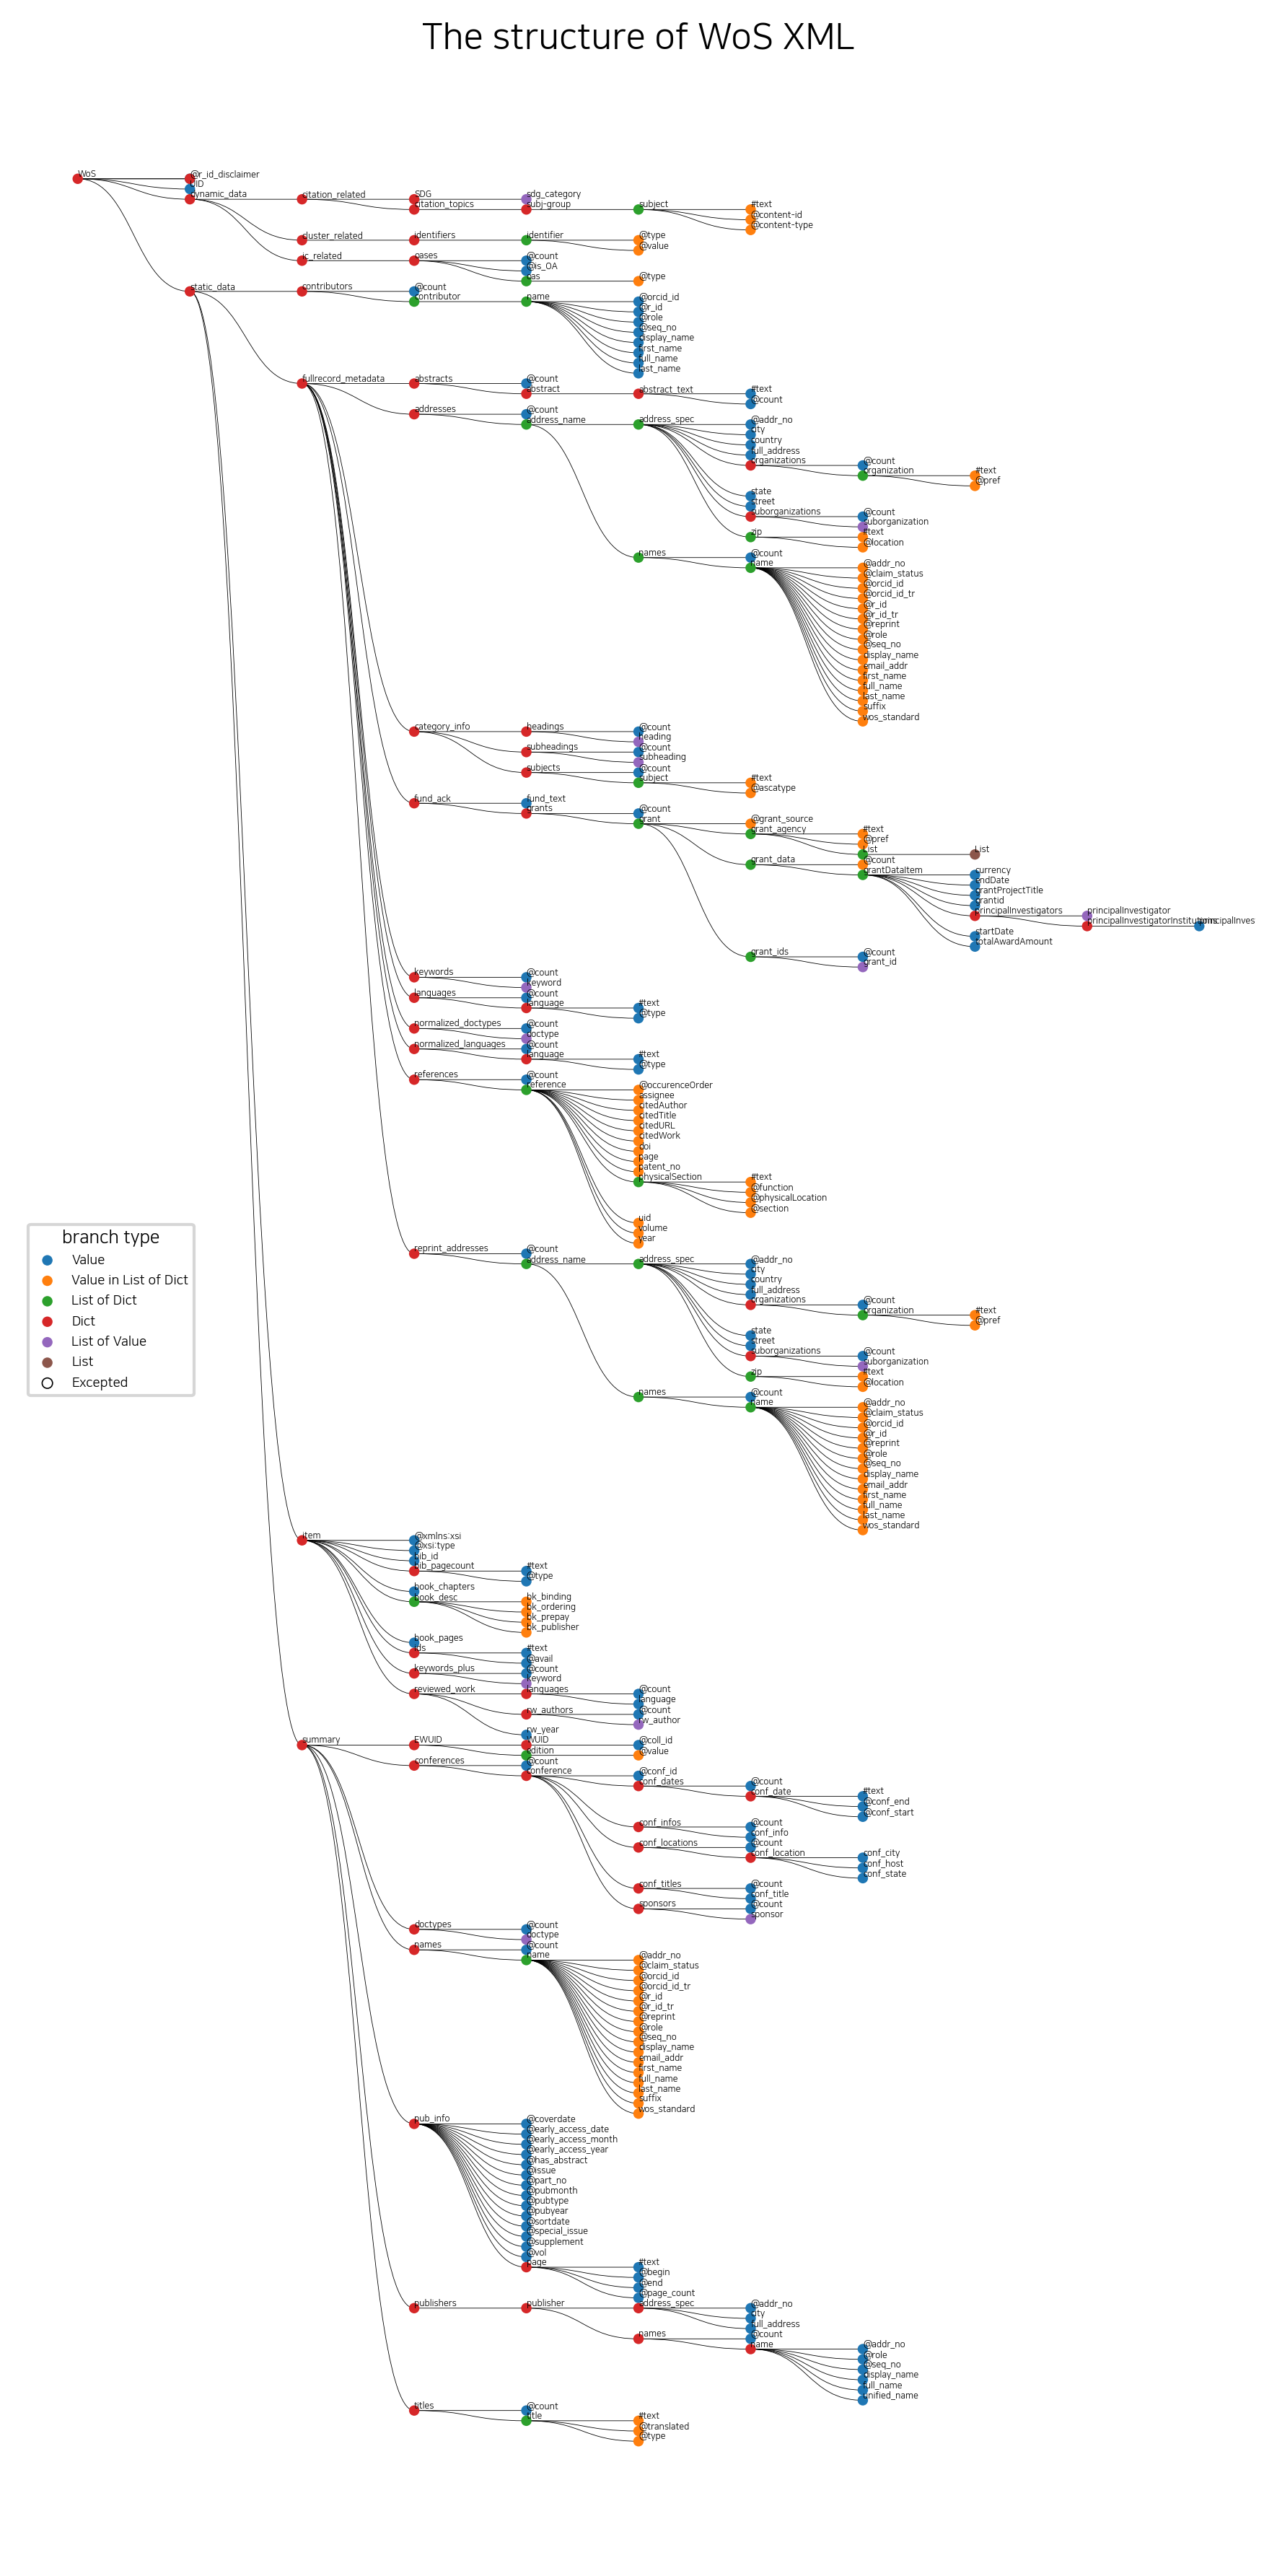

In [1279]:
except_keys = []
origin = 'WoS'
fig = plot.plot_schema(excepted_reg[0], data_name=origin, origin=origin, except_keys=except_keys, forced={},
          legend_loc='center left', node_size=12, font_size=3, X_SIZE=6, Y_SIZE=12, DPI=300
                )
plt.tight_layout()
# plt.savefig("Structure_WoS_XML.svg")

In [787]:
count_dict = {
            'Value':1, 'Value in List of Dict':1, 'List of Dict':0, 'Dict':0, 'List of Value':1, 'List':1
        }

plot.get_position_grid(types, origin, count_dict)

type  \
rank_1           rank_2           rank_3 rank_4 rank_5      rank_6 rank_7 rank_8 rank_9 rank_10                          
@r_id_disclaimer                                                                                                 Value   
UID                                                                                                              Value   
dynamic_data                                                                                                      Dict   
                 citation_related                                                                                 Dict   
                                  SDG                                                                             Dict   
...                                                                                                                ...   
static_data      summary          titles @count                                                                  Value   
                                         title                                                            List of Dict   
                                                #text                                            Value in List of Dict   
                                                @translated                                      Value in List of Dict   
                                                @type                                            Value in List of Dict   

                                                                                                 depth  \
rank_1           rank_2           rank_3 rank_4 rank_5      rank_6 rank_7 rank_8 rank_9 rank_10          
@r_id_disclaimer                                                                                     1   
UID                                                                                                  1   
dynamic_data                                                                                         1   
                 citation_related                                                                    2   
                                  SDG                                                                3   
...                                                                                                ...   
static_data      summary          titles @count                                                      4   
                                         title                                                       4   
                                                #text                                                5   
                                                @translated                                          5   
                                                @type                                                5   

                                                                                                 cnt  
rank_1           rank_2           rank_3 rank_4 rank_5      rank_6 rank_7 rank_8 rank_9 rank_10       
@r_id_disclaimer                                                                                   1  
UID                                                                                                1  
dynamic_data                                                                                       9  
                 citation_related                                                                  4  
                                  SDG                                                              1  
...                                                                                              ...  
static_data      summary          titles @count                                                    1  
                                         title                                                     3  
                                                #text                                              1  
               

In [786]:
_ = processing.json_to_key_pairs(excepted_reg[0], parent=origin, parent_type='Dict', sep=sep)
__ = processing.key_pair_to_df(_)
# __.reset_index().set_index('branch')['type']['@r_id_disclaimer']
__

,parent,branch,note,type
0,WoS,@r_id_disclaimer,,Value
1,WoS,UID,,Value
2,WoS,WoS,,Dict
3,WoS,dynamic_data,,Dict
4,WoS,static_data,,Dict
...,...,...,...,...
257,static_data__summary__publishers__publisher__n...,static_data__summary__publishers__publisher__n...,,Value
258,static_data__summary__publishers__publisher__n...,static_data__summary__publishers__publisher__n...,,Value
259,static_data__summary__publishers__publisher__n...,static_data__summary__publishers__publisher__n...,,Value
260,static_data__summary__titles,static_data__summary__titles__@count,,Value


In [597]:
jsons[3]

{'@r_id_disclaimer': 'ResearcherID data provided by Clarivate Analytics',
 'UID': 'WOS:000997477300001',
 'static_data': {'summary': {'EWUID': {'WUID': {'@coll_id': 'WOS'},
    'edition': [{'@value': 'WOS.SCI'}, {'@value': 'WOS.SSCI'}]},
   'pub_info': {'@sortdate': '2023-05-16',
    '@pubyear': '2023',
    '@has_abstract': 'Y',
    '@coverdate': 'MAY 16 2023',
    '@pubmonth': 'MAY 16',
    '@vol': '15',
    '@issue': '10',
    '@pubtype': 'Journal',
    'page': {'@page_count': '16'}},
   'titles': {'@count': '6',
    'title': [{'@type': 'source', '#text': 'SUSTAINABILITY'},
     {'@type': 'source_abbrev', '#text': 'SUSTAINABILITY-BASEL'},
     {'@type': 'abbrev_iso', '#text': 'Sustainability'},
     {'@type': 'abbrev_11', '#text': 'SUSTAINABIL'},
     {'@type': 'abbrev_29', '#text': 'SUSTAINABILITY'},
     {'@type': 'item',
      '#text': 'Economic Growing Quantity Model with Mortality in Newborn Items and Inhibition Cost of Ammonia Production under All-Units Discount Policy'}]},
   

In [692]:
types.loc['static_data__fullrecord_metadata__addresses__address_name__address_spec__zip']

'List of Dict'

In [1226]:
def excepted_regularization(_jsons, types, base_key='', sep='__'):
    def __init__():
        _res = {}
        for branch in types.index:
            keys = branch.split(sep)[:]
            __type = types[branch]
            __res = _res
            for key in keys[:-1]:
                if isinstance(__res, list):
                    __res = __res[0]
                    # pass
                # else:
                try:
                    __res = __res[key]
                except:
                    __res[key] = {}
                    __res = __res[key]
                # if len(keys) > 0:
                #     fkey = keys[-1]
                #     if fkey == '@orcid_id':
                #         print(__type, keys)
                #         print(key, __res)
                #         try:
                #             print(__res[key])
                #         except:
                #             print('~~~~')
            if len(keys) > 0:
                fkey = keys[-1]
                if isinstance(__res, list):
                    __res = __res[0]
                
                if __type == 'Value':
                    __res[fkey] = ''
                elif __type == 'List of Value':
                    __res[fkey] = []
                elif __type == 'List of Dict': # Assume I: 'Values in List of Dict' is not empty
                    __res[fkey] = [{}]
                    # if fkey == 'name':
                    #     print(__type, keys)
                    #     print(__res)
                elif __type == 'Value in List of Dict':
                    __res[fkey] = ''
                    # if fkey == '@r_id':
                    #     print(__type, keys)
                    #     print(__res)
                elif __type == 'Dict':
                    __res[fkey] = {}
                else: # List
                    __res[fkey] = []
                
                if isinstance(__res, list):
                    __res = __res[0]
                
        return _res

    
    def insert_value(data, __res, full_key=''):
        if isinstance(data, dict):
            for k, v in data.items():
                if full_key != '':
                    _full_key = full_key+sep+k
                else:
                    _full_key = k
                
                if types[_full_key] == 'Value':
                    __res[k] += v
                elif types[_full_key] == 'List of Dict': # 'Value in List of Dict' is included here with Assume I
                    # __res[k] += [v]
                    # print(__res[k], v)
                    if __res[k][0] == {}:
                        __res[k][0] = v
                    else:
                        __res[k] += v
                    # __res[k].append(v)
                else:
                    insert_value(v, __res[k], _full_key)
        elif isinstance(data, list):
            if types[full_key] == 'List of Value':
                __res += data
            elif types[full_key] == 'List of Dict': # 'Value in List of Dict' is included here with Assume I
                # __res += data
                if __res[0] == {}:
                    __res[0] == data
                else:
                    __res.append(data)
        else:
            if types[full_key] == 'List of Value':
                __res += [data]

    result = []

    format = __init__()
    # print(format)
    for _json in _jsons:
        _res = format.copy()
        insert_value(_json, _res, base_key)
        result.append(_res)
    return result

In [647]:
{'@r_id_disclaimer': '', 'UID': '', 'dynamic_data': {'citation_related': {'SDG': {'sdg_category': []}, 'citation_topics': {'subj-group': {'subject': [{'#text': '', '@content-id': '', '@content-type': ''}]}}}, 'cluster_related': {'identifiers': {'identifier': [{'@type': '', '@value': ''}]}}, 'ic_related': {'oases': {'@count': '', '@is_OA': '', 'oas': [{'@type': ''}]}}}, 'static_data': {'contributors': {'@count': '', 'contributor': [{'name': {}, '@orcid_id': '', '@r_id': '', '@role': '', '@seq_no': '', 'display_name': '', 'first_name': '', 'full_name': '', 'last_name': ''}]}, 'fullrecord_metadata': {'abstracts': {'@count': '', 'abstract': {'abstract_text': {'#text': '', '@count': ''}}}, 'addresses': {'@count': '', 'address_name': [{'address_spec': {}, 'names': {}, '@addr_no': '', 'city': '', 'country': '', 'full_address': '', 'organizations': {'@count': '', 'organization': [{'#text': '', '@pref': ''}]}, 'state': '', 'street': '', 'suborganizations': {'@count': '', 'suborganization': []}, 'zip': [{'#text': '', '@location': ''}], '@count': '', 'name': [{'@addr_no': '', '@claim_status': '', '@orcid_id': '', '@orcid_id_tr': '', '@r_id': '', '@r_id_tr': '', '@reprint': '', '@role': '', '@seq_no': '', 'display_name': '', 'email_addr': '', 'first_name': '', 'full_name': '', 'last_name': '', 'suffix': '', 'wos_standard': ''}]}]}, 'category_info': {'headings': {'@count': '', 'heading': []}, 'subheadings': {'@count': '', 'subheading': []}, 'subjects': {'@count': '', 'subject': [{'#text': '', '@ascatype': ''}]}}, 'fund_ack': {'fund_text': '', 'grants': {'@count': '', 'grant': [{'@grant_source': '', 'grant_agency': '', 'grant_data': '', 'grant_ids': {}, '#text': '', '@pref': '', 'List': [], '@count': '', 'grantDataItem': {'currency': '', 'endDate': '', 'grantProjectTitle': '', 'grantid': '', 'principalInvestigators': {'principalInvestigator': [], 'principalInvestigatorInstitutions': {'principalInvestigatorInstitution': ''}}, 'startDate': '', 'totalAwardAmount': ''}, 'grant_id': []}]}}, 'keywords': {'@count': '', 'keyword': []}, 'languages': {'@count': '', 'language': {'#text': '', '@type': ''}}, 'normalized_doctypes': {'@count': '', 'doctype': []}, 'normalized_languages': {'@count': '', 'language': {'#text': '', '@type': ''}}, 'references': {'@count': '', 'reference': [{'@occurenceOrder': '', 'assignee': '', 'citedAuthor': '', 'citedTitle': '', 'citedURL': '', 'citedWork': '', 'doi': '', 'page': '', 'patent_no': '', 'physicalSection': '', 'uid': '', 'volume': '', 'year': '', '#text': [{}], '@function': [{}], '@physicalLocation': [{}], '@section': [{}]}]}, 'reprint_addresses': {'@count': '', 'address_name': [{'address_spec': {}, 'names': {}, '@addr_no': '', 'city': '', 'country': '', 'full_address': '', 'organizations': {'@count': '', 'organization': [{'#text': '', '@pref': ''}]}, 'state': '', 'street': '', 'suborganizations': {'@count': '', 'suborganization': []}, 'zip': [{'#text': '', '@location': ''}], '@count': '', 'name': [{'@addr_no': '', '@claim_status': '', '@orcid_id': '', '@r_id': '', '@reprint': '', '@role': '', '@seq_no': '', 'display_name': '', 'email_addr': '', 'first_name': '', 'full_name': '', 'last_name': '', 'wos_standard': ''}]}]}}, 'item': {'@xmlns:xsi': '', '@xsi:type': '', 'bib_id': '', 'bib_pagecount': {'#text': '', '@type': ''}, 'book_chapters': '', 'book_desc': [{'bk_binding': '', 'bk_ordering': '', 'bk_prepay': '', 'bk_publisher': ''}], 'book_pages': '', 'ids': {'#text': '', '@avail': ''}, 'keywords_plus': {'@count': '', 'keyword': []}, 'reviewed_work': {'languages': {'@count': '', 'language': ''}, 'rw_authors': {'@count': '', 'rw_author': []}, 'rw_year': ''}}, 'summary': {'EWUID': {'WUID': {'@coll_id': ''}, 'edition': [{'@value': ''}]}, 'conferences': {'@count': '', 'conference': {'@conf_id': '', 'conf_dates': {'@count': '', 'conf_date': {'#text': '', '@conf_end': '', '@conf_start': ''}}, 'conf_infos': {'@count': '', 'conf_info': ''}, 'conf_locations': {'@count': '', 'conf_location': {'conf_city': '', 'conf_host': '', 'conf_state': ''}}, 'conf_titles': {'@count': '', 'conf_title': ''}, 'sponsors': {'@count': '', 'sponsor': []}}}, 'doctypes': {'@count': '', 'doctype': []}, 'names': {'@count': '', 'name': [{'@addr_no': '', '@claim_status': '', '@orcid_id': '', '@orcid_id_tr': '', '@r_id': '', '@r_id_tr': '', '@reprint': '', '@role': '', '@seq_no': '', 'display_name': '', 'email_addr': '', 'first_name': '', 'full_name': '', 'last_name': '', 'suffix': '', 'wos_standard': ''}]}, 'pub_info': {'@coverdate': '', '@early_access_date': '', '@early_access_month': '', '@early_access_year': '', '@has_abstract': '', '@issue': '', '@part_no': '', '@pubmonth': '', '@pubtype': '', '@pubyear': '', '@sortdate': '', '@special_issue': '', '@supplement': '', '@vol': '', 'page': {'#text': '', '@begin': '', '@end': '', '@page_count': ''}}, 'publishers': {'publisher': {'address_spec': {'@addr_no': '', 'city': '', 'full_address': ''}, 'names': {'@count': '', 'name': {'@addr_no': '', '@role': '', '@seq_no': '', 'display_name': '', 'full_name': '', 'unified_name': ''}}}}, 'titles': {'@count': '', 'title': [{'#text': '', '@translated': '', '@type': ''}]}}}}

{'@r_id_disclaimer': '',
 'UID': '',
 'dynamic_data': {'citation_related': {'SDG': {'sdg_category': []},
   'citation_topics': {'subj-group': {'subject': [{'#text': '',
       '@content-id': '',
       '@content-type': ''}]}}},
  'cluster_related': {'identifiers': {'identifier': [{'@type': '',
      '@value': ''}]}},
  'ic_related': {'oases': {'@count': '',
    '@is_OA': '',
    'oas': [{'@type': ''}]}}},
 'static_data': {'contributors': {'@count': '',
   'contributor': [{'name': {},
     '@orcid_id': '',
     '@r_id': '',
     '@role': '',
     '@seq_no': '',
     'display_name': '',
     'first_name': '',
     'full_name': '',
     'last_name': ''}]},
  'fullrecord_metadata': {'abstracts': {'@count': '',
    'abstract': {'abstract_text': {'#text': '', '@count': ''}}},
   'addresses': {'@count': '',
    'address_name': [{'address_spec': {},
      'names': {},
      '@addr_no': '',
      'city': '',
      'country': '',
      'full_address': '',
      'organizations': {'@count': '',
  

In [223]:
Counter([x.split('__')[-1] for x in branches]).most_common(100)

[('@count', 37),
 ('#text', 16),
 ('@addr_no', 7),
 ('@type', 6),
 ('full_name', 5),
 ('display_name', 5),
 ('@seq_no', 5),
 ('@role', 5),
 ('name', 5),
 ('last_name', 4),
 ('first_name', 4),
 ('@r_id', 4),
 ('@orcid_id', 4),
 ('names', 4),
 ('email_addr', 3),
 ('suffix', 3),
 ('wos_standard', 3),
 ('@reprint', 3),
 ('@claim_status', 3),
 ('language', 3),
 ('@pref', 3),
 ('address_spec', 3),
 ('city', 3),
 ('full_address', 3),
 ('address_name', 2),
 ('@orcid_id_tr', 2),
 ('@r_id_tr', 2),
 ('keyword', 2),
 ('@location', 2),
 ('doctype', 2),
 ('zip', 2),
 ('suborganization', 2),
 ('organization', 2),
 ('page', 2),
 ('@value', 2),
 ('subject', 2),
 ('suborganizations', 2),
 ('street', 2),
 ('state', 2),
 ('organizations', 2),
 ('country', 2),
 ('languages', 2),
 ('grant_agency', 1),
 ('heading', 1),
 ('bk_binding', 1),
 ('book_desc', 1),
 ('bk_ordering', 1),
 ('bk_prepay', 1),
 ('rw_author', 1),
 ('grant_ids', 1),
 ('book_note', 1),
 ('bk_publisher', 1),
 ('subheading', 1),
 ('grantDataIt

In [235]:
temp3.groupby(cols[:-1]).sum()[['total']].sort_values('total')[::-1].reset_index()

,Dict,List,List of Dict,List of Value,Value,Value in List of Dict,total
0,0,0,0,0,1,1,154
1,0,0,0,0,1,0,108
2,1,0,0,0,0,0,54
3,1,0,1,0,0,0,34
4,0,0,0,1,1,0,28
5,1,0,0,0,0,1,24
6,0,0,0,0,0,1,19
7,0,0,1,0,1,0,12
8,0,0,1,0,0,0,8
9,0,0,1,0,0,1,4


# Grouping

- Value vs Value in List of Dict
  - Possible
- Dict vs List of Dict
  - Possible (Pair with bottom)
- List of Value vs Value
  - Possible
- Dict vs Value in List of Dict
  - Need to Check
- List of Dict vs Value
- List of Dict vs Value in List of Dict
- 

In [260]:
msk = (temp3[cols[:-1]] == (0,0,0,0,1,1)).all(axis=1)
tg_keys = temp3[msk].name[::10].values
# msk

In [295]:
def get_item(item, key, sep='__'):
    def __get_subItem__(__item__, __key__):
        if isinstance(__key__, list) & (len(__key__) > 0):
            if isinstance(__item__, list):
                print(__key__[0], 'List')
                return [__get_subItem__(__item__[i][__key__[0]], __key__[1:]) for i, x in enumerate(__item__)]
            elif isinstance(__item__, dict):
                print(__key__[0], 'Dict')
                return __get_subItem__(__item__[__key__[0]], __key__[1:])
            else:
                return __item__
        else:
            if isinstance(__item__, list):
                print(__key__, 'Value in List')
                return [__item__[i] for i, x in enumerate(__item__)]
            else:
                print(__key__, 'Value')
                return __item__
            
    keys = key.split(sep)
    if keys[0] == '':
        keys = keys[1:]
    return __get_subItem__(item, keys)
get_item(jsons[0], '__static_data__fullrecord_metadata__addresses__address_name__names__name__@seq_no')

static_data Dict
fullrecord_metadata Dict
addresses Dict
address_name Dict
names List
name Dict
@seq_no List
[] Value
[] Value
[] Value
name Dict
@seq_no List
[] Value
[] Value


[['1', '2', '5'], ['3', '4']]

In [310]:
get_item(jsons[1], '__static_data__fullrecord_metadata__fund_ack__grants__grant__grant_agency')

static_data Dict
fullrecord_metadata Dict
fund_ack Dict
grants Dict
grant Dict
grant_agency Dict
[] Value in List


['Scientific Research Fund of Suleyman Demirel University',
 {'@pref': 'Y', '#text': 'Suleyman Demirel University'}]

In [ ]:
    
    

# get_item(jsons[0], tg_keys[2])
get_item(jsons[0], '__static_data__fullrecord_metadata__addresses__address_name__names')

In [281]:
tg_keys[2]

'__static_data__fullrecord_metadata__addresses__address_name__names__name__@seq_no'

In [276]:
print(jsons[0])

{'@r_id_disclaimer': 'ResearcherID data provided by Clarivate Analytics', 'UID': 'WOS:001037010200001', 'static_data': {'summary': {'EWUID': {'WUID': {'@coll_id': 'WOS'}, 'edition': {'@value': 'WOS.SCI'}}, 'pub_info': {'@sortdate': '2023-07-26', '@pubyear': '2023', '@has_abstract': 'Y', '@coverdate': 'JUL 26 2023', '@pubmonth': 'JUL 26', '@early_access_date': 'JUL 2023', '@early_access_month': '07', '@early_access_year': '2023', '@pubtype': 'Journal', 'page': {'@page_count': '9'}}, 'titles': {'@count': '6', 'title': [{'@type': 'source', '#text': 'MODERN PHYSICS LETTERS B'}, {'@type': 'source_abbrev', '#text': 'MOD PHYS LETT B'}, {'@type': 'abbrev_iso', '#text': 'Mod. Phys. Lett. B'}, {'@type': 'abbrev_11', '#text': 'MOD PHY L B'}, {'@type': 'abbrev_29', '#text': 'MOD PHYS LETT B'}, {'@type': 'item', '#text': 'Study of propagation of skew cosh Gaussian laser beam in attenuated magneto plasma'}]}, 'names': {'@count': '5', 'name': [{'@seq_no': '1', '@role': 'author', '@addr_no': '1', '@r_

In [ ]:
{'@r_id_disclaimer': 'ResearcherID data provided by Clarivate Analytics', 'UID': 'WOS:001037010200001', 'static_data': {'summary': {'EWUID': {'WUID': {'@coll_id': 'WOS'}, 'edition': {'@value': 'WOS.SCI'}}, 'pub_info': {'@sortdate': '2023-07-26', '@pubyear': '2023', '@has_abstract': 'Y', '@coverdate': 'JUL 26 2023', '@pubmonth': 'JUL 26', '@early_access_date': 'JUL 2023', '@early_access_month': '07', '@early_access_year': '2023', '@pubtype': 'Journal', 'page': {'@page_count': '9'}}, 'titles': {'@count': '6', 'title': [{'@type': 'source', '#text': 'MODERN PHYSICS LETTERS B'}, {'@type': 'source_abbrev', '#text': 'MOD PHYS LETT B'}, {'@type': 'abbrev_iso', '#text': 'Mod. Phys. Lett. B'}, {'@type': 'abbrev_11', '#text': 'MOD PHY L B'}, {'@type': 'abbrev_29', '#text': 'MOD PHYS LETT B'}, {'@type': 'item', '#text': 'Study of propagation of skew cosh Gaussian laser beam in attenuated magneto plasma'}]}, 'names': {'@count': '5', 'name': [{'@seq_no': '1', '@role': 'author', '@addr_no': '1', '@r_id': 'IGW-0587-2023', '@claim_status': 'false', '@orcid_id_tr': '0000-0001-8177-9797', 'display_name': 'Takale, Prasad', 'full_name': 'Takale, Prasad', 'wos_standard': 'Takale, P', 'first_name': 'Prasad', 'last_name': 'Takale', 'email_addr': 'prasadtakale993@gmail.com'}, {'@seq_no': '2', '@role': 'author', '@addr_no': '1', '@r_id': 'IZR-5436-2023', '@claim_status': 'false', 'display_name': 'Khandale, Kalyani', 'full_name': 'Khandale, Kalyani', 'wos_standard': 'Khandale, K', 'first_name': 'Kalyani', 'last_name': 'Khandale', 'email_addr': 'kalyanikhandale95@gmail.com'}, {'@seq_no': '3', '@role': 'author', '@addr_no': '2', '@r_id': 'JAA-5667-2023', '@claim_status': 'false', 'display_name': 'Patil, Sanyogita', 'full_name': 'Patil, Sanyogita', 'wos_standard': 'Patil, S', 'first_name': 'Sanyogita', 'last_name': 'Patil', 'email_addr': 'sanyogitaspatil@gmail.com'}, {'@seq_no': '4', '@role': 'author', '@addr_no': '2', '@r_id': 'IPG-1325-2023', '@claim_status': 'false', 'display_name': 'Patil, Sandip', 'full_name': 'Patil, Sandip', 'wos_standard': 'Patil, S', 'first_name': 'Sandip', 'last_name': 'Patil', 'email_addr': 'sdpatilphy@gmail.com'}, {'@seq_no': '5', '@role': 'author', '@reprint': 'Y', '@addr_no': '1', '@r_id': 'CCE-1348-2022', '@orcid_id': '0000-0002-2545-010X', '@claim_status': 'false', '@orcid_id_tr': '0000-0002-2545-010X', 'display_name': 'Takale, Mansing', 'full_name': 'Takale, Mansing', 'wos_standard': 'Takale, M', 'first_name': 'Mansing', 'last_name': 'Takale', 'email_addr': 'mvtphyunishivaji@gmail.com'}]}, 'doctypes': {'@count': '2', 'doctype': ['Article', 'Early Access']}, 'publishers': {'publisher': {'address_spec': {'@addr_no': '1', 'full_address': '5 TOH TUCK LINK, SINGAPORE 596224, SINGAPORE', 'city': 'SINGAPORE'}, 'names': {'@count': '1', 'name': {'@role': 'publisher', '@seq_no': '1', '@addr_no': '1', 'display_name': 'WORLD SCIENTIFIC PUBL CO PTE LTD', 'full_name': 'WORLD SCIENTIFIC PUBL CO PTE LTD', 'unified_name': 'World Scientific'}}}}}, 'fullrecord_metadata': {'languages': {'@count': '1', 'language': {'@type': 'primary', '#text': 'English'}}, 'normalized_languages': {'@count': '1', 'language': {'@type': 'primary', '#text': 'English'}}, 'normalized_doctypes': {'@count': '2', 'doctype': ['Article', 'Early Access']}, 'references': {'@count': '36', 'reference': [{'@occurenceOrder': '15', 'uid': 'WOS:000471988700016', 'citedAuthor': 'Thakur, V', 'year': '2019', 'page': '736', 'volume': '71', 'citedTitle': 'Relativistic Self-Focusing of Hermite-cosine-Gaussian Laser Beam in Collisionless Plasma with Exponential Density Transition', 'citedWork': 'COMMUNICATIONS IN THEORETICAL PHYSICS', 'doi': '10.1088/0253-6102/71/6/736'}, {'@occurenceOrder': '13', 'uid': 'WOS:000261803400005', 'citedAuthor': 'Patil, S', 'year': '2008', 'page': '3529', 'volume': '55', 'citedTitle': 'Propagation of Hermite-cosh-Gaussian laser beams in non-degenerate germanium having space charge neutrality', 'citedWork': 'JOURNAL OF MODERN OPTICS', 'doi': '10.1080/09500340802318333'}, {'@occurenceOrder': '31', 'uid': 'WOS:000341154100069', 'citedAuthor': 'Sefkow, AB', 'year': '2014', 'page': 'ARTN 072711', 'volume': '21', 'citedTitle': 'Design of magnetized liner inertial fusion experiments using the Z facility', 'citedWork': 'PHYSICS OF PLASMAS', 'doi': '10.1063/1.4890298'}, {'@occurenceOrder': '28', 'uid': 'WOS:000900094000001', 'citedAuthor': 'Khandale, KY', 'year': '2022', 'page': '967', 'volume': '60', 'citedTitle': 'Analytical Study of Skew-cosh-Gaussian Laser Beam Propagation through Collisionless Plasma', 'citedWork': 'INDIAN JOURNAL OF PURE & APPLIED PHYSICS', 'doi': '10.56042/ijpap.v60i12.67362'}, {'@occurenceOrder': '14', 'uid': 'WOS:000428987800063', 'citedAuthor': 'Valkunde, AT', 'year': '2018', 'page': 'ARTN 033103', 'volume': '25', 'citedTitle': 'Analytical investigation on domain of decentered parameter for self-focusing of Hermite-cosh-Gaussian laser beam in collisional plasma', 'citedWork': 'PHYSICS OF PLASMAS', 'doi': '10.1063/1.5016938'}, {'@occurenceOrder': '27', 'uid': 'WOS:000890292000002', 'citedAuthor': 'Khandale, KY', 'year': '2023', 'page': 'ARTN 13', 'volume': '53', 'citedTitle': 'Analytical Investigation of Domains of the Order of Skew-Cosh-Gaussian Laser Beams for Relativistic Self-focusing/Defocusing in Homogeneous Plasma', 'citedWork': 'BRAZILIAN JOURNAL OF PHYSICS', 'doi': '10.1007/s13538-022-01223-3'}, {'@occurenceOrder': '2', 'uid': 'WOS:000707057500015', 'citedAuthor': 'Kumar, A', 'year': '2021', 'page': 'ARTN 617', 'volume': '53', 'citedTitle': 'Laser wakefield and direct laser acceleration of electron in plasma bubble regime with circularly polarized laser pulse', 'citedWork': 'OPTICAL AND QUANTUM ELECTRONICS', 'doi': '10.1007/s11082-021-03241-y'}, {'@occurenceOrder': '3', 'uid': 'WOS:000814823200001', 'citedAuthor': 'Singh, M', 'year': '2022', 'page': 'ARTN 085001', 'volume': '32', 'citedTitle': 'Optical second-and third harmonic radiation generation in a laser-produced plasma', 'citedWork': 'LASER PHYSICS', 'doi': '10.1088/1555-6611/ac787a'}, {'@occurenceOrder': '17', 'uid': '001037010200001.17', 'citedAuthor': 'Khandale, K. Y.', 'year': '2022', 'page': '375', 'volume': '49', 'citedWork': 'Bulg. J. Phys.'}, {'@occurenceOrder': '10', 'uid': 'WOS:000296129000024', 'citedAuthor': 'Patil, SD', 'year': '2011', 'page': '1869', 'volume': '122', 'citedTitle': 'Cross focusing of two coaxial cosh-Gaussian laser beams in a parabolic medium', 'citedWork': 'OPTIK', 'doi': '10.1016/j.ijleo.2010.12.030'}, {'@occurenceOrder': '7', 'uid': 'WOS:000430761500126', 'citedAuthor': 'Valkunde, AT', 'year': '2018', 'page': '1034', 'volume': '158', 'citedTitle': 'Exponential density transition based self-focusing of Gaussian laser beam in collisional plasma', 'citedWork': 'OPTIK', 'doi': '10.1016/j.ijleo.2017.12.183'}, {'@occurenceOrder': '21', 'uid': 'WOS:000382447800075', 'citedAuthor': 'Jafari, MJ', 'year': '2016', 'page': 'ARTN 073119', 'volume': '23', 'citedTitle': 'Evolution of a Gaussian laser beam in warm collisional magnetoplasma', 'citedWork': 'PHYSICS OF PLASMAS', 'doi': '10.1063/1.4959867'}, {'@occurenceOrder': '19', 'uid': 'WOS:000880782400003', 'citedAuthor': 'Nikam, PP', 'year': '2022', 'page': '576', 'volume': '60', 'citedTitle': 'Effect of Asymmetry in the Modulation Parameters on Self-Focusing of Asymmetric Finite Airy-Gaussian Laser Beam in Collisionless Plasma', 'citedWork': 'INDIAN JOURNAL OF PURE & APPLIED PHYSICS', 'doi': '10.5481/indian.5487'}, {'@occurenceOrder': '4', 'uid': 'WOS:A1990CW47700026', 'citedAuthor': 'SUCKEWER, S', 'year': '1990', 'page': '1553', 'volume': '247', 'citedTitle': 'SOFT-X-RAY LASERS AND THEIR APPLICATIONS', 'citedWork': 'SCIENCE'}, {'@occurenceOrder': '16', 'uid': '001037010200001.16', 'citedAuthor': 'Aggarwal, M.', 'year': '2006', 'volume': '2018', 'citedWork': 'AIP Conf. Proc.'}, {'@occurenceOrder': '9', 'uid': 'WOS:000445714700025', 'citedAuthor': 'Thakur, V', 'year': '2018', 'page': '191', 'volume': '172', 'citedTitle': 'Stronger self-focusing of a chirped pulse laser with exponential density ramp profile in cold quantum magnetoplasma', 'citedWork': 'OPTIK', 'doi': '10.1016/j.ijleo.2018.07.027'}, {'@occurenceOrder': '22', 'uid': 'WOS:000518798500154', 'citedAuthor': 'Vhanmore, BD', 'year': '2019', 'page': 'ARTN 110017', 'volume': '2142', 'citedTitle': 'Self-Focusing of Asymmetric Cosh-Gaussian Laser Beams in Weakly Ionized Collisional Magnetized Plasma', 'citedWork': 'ADVANCES IN BASIC SCIENCES (ICABS 2019)', 'doi': '10.1063/1.5122477'}, {'@occurenceOrder': '5', 'uid': 'WOS:000305773200017', 'citedAuthor': 'Navare, ST', 'year': '2012', 'page': '1316', 'volume': '50', 'citedTitle': 'Impact of linear absorption on self-focusing of Gaussian laser beam in collisional plasma', 'citedWork': 'OPTICS AND LASERS IN ENGINEERING', 'doi': '10.1016/j.optlaseng.2012.02.015'}, {'@occurenceOrder': '20', 'uid': 'WOS:000364403600082', 'citedAuthor': 'Abari, ME', 'year': '2015', 'page': 'ARTN 103112', 'volume': '22', 'citedTitle': 'Self-focusing and defocusing of Gaussian laser beams in collisional underdense magnetized plasmas with considering the nonlinear ohmic heating and ponderomotive force effects', 'citedWork': 'PHYSICS OF PLASMAS', 'doi': '10.1063/1.4933357'}, {'@occurenceOrder': '34', 'uid': 'WOS:000403568400003', 'citedAuthor': 'Ivanov, VV', 'year': '2017', 'page': 'ARTN 085008', 'volume': '59', 'citedTitle': 'Generation of disc-like plasma from laser-matter interaction in the presence of a strong external magnetic field', 'citedWork': 'PLASMA PHYSICS AND CONTROLLED FUSION', 'doi': '10.1088/1361-6587/aa7358'}, {'@occurenceOrder': '11', 'uid': 'WOS:000360216500016', 'citedAuthor': 'Kant, N', 'year': '2015', 'page': '103', 'volume': '64', 'citedTitle': 'Density Transition Based Self-Focusing of cosh-Gaussian Laser Beam in Plasma with Linear Absorption', 'citedWork': 'COMMUNICATIONS IN THEORETICAL PHYSICS'}, {'@occurenceOrder': '18', 'uid': 'WOS:000368650800183', 'citedAuthor': 'Aggarwal, M', 'year': '2015', 'page': '5710', 'volume': '126', 'citedTitle': 'Propagation of circularly polarized quadruple Gaussian laser beam in magnetoplasma', 'citedWork': 'OPTIK', 'doi': '10.1016/j.ijleo.2015.08.141'}, {'@occurenceOrder': '32', 'uid': 'WOS:000343041100037', 'citedAuthor': 'Albertazzi, B', 'year': '2014', 'page': '325', 'volume': '346', 'citedTitle': 'Laboratory formation of a scaled protostellar jet by coaligned poloidal magnetic field', 'citedWork': 'SCIENCE', 'doi': '10.1126/science.1259694'}, {'@occurenceOrder': '8', 'uid': 'WOS:000377734100057', 'citedAuthor': 'Wani, MA', 'year': '2016', 'page': '6710', 'volume': '127', 'citedTitle': 'Nonlinear propagation of Gaussian laser beam in an inhomogeneous plasma under plasma density ramp', 'citedWork': 'OPTIK', 'doi': '10.1016/j.ijleo.2016.04.141'}, {'@occurenceOrder': '33', 'uid': 'WOS:000474440600022', 'citedAuthor': 'Ivanov, VV', 'year': '2019', 'page': 'ARTN 062707', 'volume': '26', 'citedTitle': 'Study of laser produced plasma in a longitudinal magnetic field', 'citedWork': 'PHYSICS OF PLASMAS', 'doi': '10.1063/1.5091702'}, {'@occurenceOrder': '30', 'uid': 'WOS:000292764600004', 'citedAuthor': 'Chang, PY', 'year': '2011', 'page': 'ARTN 035006', 'volume': '107', 'citedTitle': 'Fusion Yield Enhancement in Magnetized Laser-Driven Implosions', 'citedWork': 'PHYSICAL REVIEW LETTERS', 'doi': '10.1103/PhysRevLett.107.035006'}, {'@occurenceOrder': '25', 'uid': '001037010200001.25', 'citedAuthor': 'Varaki, M. A.', 'year': '2017', 'volume': '24', 'citedWork': 'Phys. Plasmas'}, {'@occurenceOrder': '26', 'uid': 'WOS:000366936800066', 'citedAuthor': 'Khomenko, E', 'year': '2015', 'page': 'ARTN A66', 'volume': '584', 'citedTitle': 'Evershed flow observed in neutral and singly ionized iron lines', 'citedWork': 'ASTRONOMY & ASTROPHYSICS', 'doi': '10.1051/0004-6361/201526437'}, {'@occurenceOrder': '1', 'uid': 'WOS:000614621000052', 'citedAuthor': 'Kamboj, O', 'year': '2019', 'page': 'ARTN 060011', 'volume': '2136', 'citedTitle': 'Strong Self-Focusing for Laser Interaction with DT Fusion Target', 'citedWork': 'INTERNATIONAL CONFERENCE ON PHOTONICS, METAMATERIALS & PLASMONICS (PMP-2019)', 'doi': '10.1063/1.5120957'}, {'@occurenceOrder': '36', 'uid': 'WOS:A1968B616900001', 'citedAuthor': 'AKHMANOV, SA', 'year': '1968', 'page': '609', 'volume': '10', 'citedTitle': 'SELF-FOCUSING AND DIFFRACTION OF LIGHT IN A NONLINEAR MEDIUM', 'citedWork': 'SOVIET PHYSICS USPEKHI-USSR'}, {'@occurenceOrder': '29', 'uid': 'WOS:000651188900001', 'citedAuthor': 'Ivanov, VV', 'year': '2021', 'page': 'ARTN 046901', 'volume': '6', 'citedTitle': 'Generation of strong magnetic fields for magnetized plasma experiments at the 1-MA pulsed power machine', 'citedWork': 'MATTER AND RADIATION AT EXTREMES', 'doi': '10.1063/5.0042863'}, {'@occurenceOrder': '12', 'uid': 'WOS:000415457700003', 'citedAuthor': 'Patil, SD', 'year': '2007', 'page': '136', 'volume': '36', 'citedTitle': 'ANALYTICAL STUDY OF HChG-LASER BEAM PROPAGATION IN COLLISIONAL AND COLLISIONLESS PLASMAS', 'citedWork': 'JOURNAL OF OPTICS-INDIA'}, {'@occurenceOrder': '35', 'uid': '001037010200001.35', 'citedAuthor': 'Sodha, M. S.', 'year': '1976', 'page': '619', 'volume': '13', 'citedWork': 'Prog. Opt.'}, {'@occurenceOrder': '6', 'uid': 'WOS:000353144100001', 'citedAuthor': 'Zare, S', 'year': '2015', 'page': 'ARTN 041301', 'volume': '18', 'citedTitle': 'Relativistic self-focusing of intense laser beam in thermal collisionless quantum plasma with ramped density profile', 'citedWork': 'PHYSICAL REVIEW SPECIAL TOPICS-ACCELERATORS AND BEAMS', 'doi': '10.1103/PhysRevSTAB.18.041301'}, {'@occurenceOrder': '24', 'uid': 'WOS:000814735700001', 'citedAuthor': 'Daraei, ME', 'year': '2022', 'page': 'ARTN e202200070', 'volume': '62', 'citedTitle': 'Influence of non-uniform magnetic field on relativistic q-Gaussian laser pulses propagating in magnetized plasmas', 'citedWork': 'CONTRIBUTIONS TO PLASMA PHYSICS', 'doi': '10.1002/ctpp.202200070'}, {'@occurenceOrder': '23', 'uid': 'WOS:A1978EX84900006', 'citedAuthor': 'TEWARI, DP', 'year': '1978', 'page': '247', 'volume': '25', 'citedTitle': 'EFFECT OF SELF-FOCUSING ON FILAMENTATION INSTABILITY IN A COLLISIONAL MAGNETOPLASMA', 'citedWork': 'OPTICA ACTA'}]}, 'addresses': {'@count': '2', 'address_name': [{'address_spec': {'@addr_no': '1', 'full_address': 'Shivaji Univ, Dept Phys, Kolhapur 416004, Maharashtra, India', 'organizations': {'@count': '3', 'organization': ['Shivaji Univ', {'@pref': 'Y', '#text': 'Shivaji University'}, {'@pref': 'D', '#text': 'Shivaji University Department of Physics'}]}, 'suborganizations': {'@count': '1', 'suborganization': 'Dept Phys'}, 'city': 'Kolhapur', 'state': 'Maharashtra', 'country': 'India', 'zip': {'@location': 'AC', '#text': '416004'}}, 'names': {'@count': '3', 'name': [{'@seq_no': '1', '@role': 'author', '@addr_no': '1', '@r_id': 'IGW-0587-2023', '@claim_status': 'false', '@orcid_id_tr': '0000-0001-8177-9797', 'display_name': 'Takale, Prasad', 'full_name': 'Takale, Prasad', 'wos_standard': 'Takale, P', 'first_name': 'Prasad', 'last_name': 'Takale', 'email_addr': 'prasadtakale993@gmail.com'}, {'@seq_no': '2', '@role': 'author', '@addr_no': '1', '@r_id': 'IZR-5436-2023', '@claim_status': 'false', 'display_name': 'Khandale, Kalyani', 'full_name': 'Khandale, Kalyani', 'wos_standard': 'Khandale, K', 'first_name': 'Kalyani', 'last_name': 'Khandale', 'email_addr': 'kalyanikhandale95@gmail.com'}, {'@seq_no': '5', '@role': 'author', '@reprint': 'Y', '@addr_no': '1', '@r_id': 'CCE-1348-2022', '@orcid_id': '0000-0002-2545-010X', '@claim_status': 'false', '@orcid_id_tr': '0000-0002-2545-010X', 'display_name': 'Takale, Mansing', 'full_name': 'Takale, Mansing', 'wos_standard': 'Takale, M', 'first_name': 'Mansing', 'last_name': 'Takale', 'email_addr': 'mvtphyunishivaji@gmail.com'}]}}, {'address_spec': {'@addr_no': '2', 'full_address': 'Devchand Coll, Dept Phys, Kolhapur 591237, Maharashtra, India', 'organizations': {'@count': '1', 'organization': 'Devchand Coll'}, 'suborganizations': {'@count': '1', 'suborganization': 'Dept Phys'}, 'city': 'Kolhapur', 'state': 'Maharashtra', 'country': 'India', 'zip': {'@location': 'AC', '#text': '591237'}}, 'names': {'@count': '2', 'name': [{'@seq_no': '3', '@role': 'author', '@addr_no': '2', '@r_id': 'JAA-5667-2023', '@claim_status': 'false', 'display_name': 'Patil, Sanyogita', 'full_name': 'Patil, Sanyogita', 'wos_standard': 'Patil, S', 'first_name': 'Sanyogita', 'last_name': 'Patil', 'email_addr': 'sanyogitaspatil@gmail.com'}, {'@seq_no': '4', '@role': 'author', '@addr_no': '2', '@r_id': 'IPG-1325-2023', '@claim_status': 'false', 'display_name': 'Patil, Sandip', 'full_name': 'Patil, Sandip', 'wos_standard': 'Patil, S', 'first_name': 'Sandip', 'last_name': 'Patil', 'email_addr': 'sdpatilphy@gmail.com'}]}}]}, 'reprint_addresses': {'@count': '1', 'address_name': {'address_spec': {'@addr_no': '1', 'full_address': 'Shivaji Univ, Dept Phys, Kolhapur 416004, Maharashtra, India', 'organizations': {'@count': '3', 'organization': ['Shivaji Univ', {'@pref': 'Y', '#text': 'Shivaji University'}, {'@pref': 'D', '#text': 'Shivaji University Department of Physics'}]}, 'suborganizations': {'@count': '1', 'suborganization': 'Dept Phys'}, 'city': 'Kolhapur', 'state': 'Maharashtra', 'country': 'India', 'zip': {'@location': 'AC', '#text': '416004'}}, 'names': {'@count': '1', 'name': {'@seq_no': '1', '@role': 'author', '@reprint': 'Y', '@addr_no': '1', '@r_id': 'IGW-0587-2023', '@claim_status': 'false', 'display_name': 'Takale, Mansing', 'full_name': 'Takale, Mansing', 'wos_standard': 'Takale, M', 'first_name': 'Mansing', 'last_name': 'Takale', 'email_addr': 'mvtphyunishivaji@gmail.com'}}}}, 'category_info': {'headings': {'@count': '1', 'heading': 'Science & Technology'}, 'subheadings': {'@count': '1', 'subheading': 'Physical Sciences'}, 'subjects': {'@count': '4', 'subject': [{'@ascatype': 'traditional', '#text': 'Physics, Applied'}, {'@ascatype': 'traditional', '#text': 'Physics, Condensed Matter'}, {'@ascatype': 'traditional', '#text': 'Physics, Mathematical'}, {'@ascatype': 'extended', '#text': 'Physics'}]}}, 'fund_ack': None, 'keywords': {'@count': '4', 'keyword': ['Skew cosh Gaussian', 'weakly ionized magnetized collisional plasma', 'self-focusing', 'exponential magnetic field']}, 'abstracts': {'@count': '1', 'abstract': {'abstract_text': {'@count': '1', '#text': '%_lt_;p%_lt_;Self-focusing of a laser beam is one of the major consequences of nonlinear interaction of laser with plasma. In this paper, self-focusing of skew cosh Gaussian (skew-ChG) laser beam is studied in anisotropic, collisional plasma where in externally exponentially decreasing magnetic field is applied. Skewness parameters in the field profile of skew-ChG laser beam eventually determine intensity profile of the beam. The symmetry in skewness parameter in two transverse directions simplifies the calculations considerably. Second order, nonlinear, ordinary, coupled differential equations for Beam Width Parameters (BWP) are obtained using Akhmanovs approach under Wentzel-Kramers-Brillouin (WKB) and paraxial approximations which are solved numerically. For given amplitude of applied magnetic field, attenuated oscillatory self-focusing is observed with respect to change in attenuation coefficient.%_lt_;/p%_lt_;/'}}}}, 'item': {'@xmlns:xsi': 'http://www.w3.org/2001/XMLSchema-instance', '@xsi:type': 'itemType_wos', 'ids': {'@avail': 'N', '#text': 'N4VO9'}, 'bib_id': ': - JUL 26 2023', 'bib_pagecount': {'@type': 'Journal', '#text': '22'}}, 'contributors': {'@count': '2', 'contributor': [{'name': {'@seq_no': '1', '@role': 'researcher_id', '@orcid_id': '0000-0002-2545-010X', 'display_name': 'Takale, Mansing', 'full_name': 'Takale, Mansing', 'first_name': 'Mansing', 'last_name': 'Takale'}}, {'name': {'@seq_no': '2', '@role': 'researcher_id', '@orcid_id': '0000-0001-8177-9797', 'display_name': 'TAKALE, PRASAD', 'full_name': 'TAKALE, PRASAD', 'first_name': 'PRASAD', 'last_name': 'TAKALE'}}]}}, 'dynamic_data': {'cluster_related': {'identifiers': {'identifier': [{'@type': 'accession_no', '@value': 'N4VO9'}, {'@type': 'issn', '@value': '0217-9849'}, {'@type': 'eissn', '@value': '1793-6640'}, {'@type': 'art_no', '@value': 'ARTN 2350185'}, {'@type': 'doi', '@value': '10.1142/S0217984923501853'}]}}, 'citation_related': {'citation_topics': {'subj-group': {'subject': [{'@content-id': '5', '@content-type': 'macro', '#text': 'Physics'}, {'@content-id': '5.107', '@content-type': 'meso', '#text': 'Laser Science'}, {'@content-id': '5.107.209', '@content-type': 'micro', '#text': 'Inertial Confinement Fusion'}]}}, 'SDG': {'sdg_category': '07 Affordable and Clean Energy'}}}}


In [ ]:
# p, sup, sub, i, 

In [127]:
tags = branches[0].split('__')[1:]
x = jsons[0]
for tag in tags:
    x = x[tag]
x

TypeError: list indices must be integers or slices, not str

In [135]:
[xi.keys() for xi in x]

[dict_keys(['@occurenceOrder', 'uid', 'citedAuthor', 'year', 'page', 'volume', 'citedTitle', 'citedWork', 'doi']),
 dict_keys(['@occurenceOrder', 'uid', 'citedAuthor', 'year', 'page', 'volume', 'citedTitle', 'citedWork', 'doi']),
 dict_keys(['@occurenceOrder', 'uid', 'citedAuthor', 'year', 'page', 'volume', 'citedTitle', 'citedWork', 'doi']),
 dict_keys(['@occurenceOrder', 'uid', 'citedAuthor', 'year', 'page', 'volume', 'citedTitle', 'citedWork', 'doi']),
 dict_keys(['@occurenceOrder', 'uid', 'citedAuthor', 'year', 'page', 'volume', 'citedTitle', 'citedWork', 'doi']),
 dict_keys(['@occurenceOrder', 'uid', 'citedAuthor', 'year', 'page', 'volume', 'citedTitle', 'citedWork', 'doi']),
 dict_keys(['@occurenceOrder', 'uid', 'citedAuthor', 'year', 'page', 'volume', 'citedTitle', 'citedWork', 'doi']),
 dict_keys(['@occurenceOrder', 'uid', 'citedAuthor', 'year', 'page', 'volume', 'citedTitle', 'citedWork', 'doi']),
 dict_keys(['@occurenceOrder', 'uid', 'citedAuthor', 'year', 'page', 'volume', '

In [153]:
_res = []
for i, _json in enumerate(jsons[:10000]):
    try:
        refs = _json['static_data']['fullrecord_metadata']['references']['reference']
        CT = [ref['citedTitle'] for ref in refs if 'citedTitle' in ref.keys()]
        __res = [ct for ct in CT if type(ct) != str]
        if len(__res) > 0:
            _res.append([i, __res])
    except:
        pass
_res

[[109,
  [{'i': 'Chloraea',
    '#text': 'The \n from Lima, a little-known species but described several times.'}]],
 [139,
  [{'i': ['Withania somnifera', 'Staphylococcus aureus'],
    '#text': 'Antioxidant and antimicrobial activities of aqueous extract of \n against methicillin-resistant \n.'}]],
 [203,
  [{'i': 'Beta vulgaris',
    '#text': 'The evaluation of stability of betalains in beetroot (\n L.) extract add to of α-, β- and γ-cyclodextrins.'}]],
 [219,
  [{'i': 'in vitro',
    '#text': 'Effects of Semen Euphorbiae and Semen Euphorbiae Pulveratun on intestinal flora \n.'}]],
 [241,
  [{'i': 'Hibiscus sabdariffa',
    '#text': 'Comparative influence of dehulling on the composition, antioxidative and functional properties of sorrel (\n L.) seed.'},
   {'i': 'Vigna unguiculata',
    '#text': 'Physicochemical and functional properties of bean flours of three cowpea (\n L. Walp) varieties in Ghana.'},
   {'i': 'Musa paradisiacae',
    '#text': 'Total antioxidant capacity, nutrition

In [444]:
jsons[5]['static_data']['fullrecord_metadata']['fund_ack']['fund_text']

'%_lt_;p%_lt_;The authors express special thanks to Guiqi Zhu (Department of Liver Surgery, Liver Cancer Institute, Zhongshan Hospital, Fudan University, Shanghai, 200032, China) for his advice on data analysis.%_lt_;/p%_lt_;/'

In [167]:
jsons[338]

{'@r_id_disclaimer': 'ResearcherID data provided by Clarivate Analytics',
 'UID': 'WOS:001026116800001',
 'static_data': {'summary': {'EWUID': {'WUID': {'@coll_id': 'WOS'},
    'edition': {'@value': 'WOS.SCI'}},
   'pub_info': {'@sortdate': '2023-01-01',
    '@pubyear': '2023',
    '@has_abstract': 'Y',
    '@coverdate': '2023',
    '@vol': '130',
    '@pubtype': 'Journal',
    'page': {'@page_count': '11'}},
   'titles': {'@count': '6',
    'title': [{'@type': 'source', '#text': 'ACTA BOTANICA MEXICANA'},
     {'@type': 'source_abbrev', '#text': 'ACTA BOT MEX'},
     {'@type': 'abbrev_iso', '#text': 'Acta. Bot. Mex.'},
     {'@type': 'abbrev_11', '#text': 'ACTA BOT ME'},
     {'@type': 'abbrev_29', '#text': 'ACTA BOT MEX'},
     {'@type': 'item',
      '#text': 'Rediscovery of<i> Chloraea</i><i> multilineolata</i> (Orchidaceae, Chloraeinae), an endangered Peruvian species'}]},
   'names': {'@count': '6',
    'name': [{'@seq_no': '1',
      '@role': 'author',
      '@addr_no': '1',
   

In [169]:
jsons[109]

{'@r_id_disclaimer': 'ResearcherID data provided by Clarivate Analytics',
 'UID': 'WOS:001026116800001',
 'static_data': {'summary': {'EWUID': {'WUID': {'@coll_id': 'WOS'},
    'edition': {'@value': 'WOS.SCI'}},
   'pub_info': {'@sortdate': '2023-01-01',
    '@pubyear': '2023',
    '@has_abstract': 'Y',
    '@coverdate': '2023',
    '@vol': '130',
    '@pubtype': 'Journal',
    'page': {'@page_count': '11'}},
   'titles': {'@count': '6',
    'title': [{'@type': 'source', '#text': 'ACTA BOTANICA MEXICANA'},
     {'@type': 'source_abbrev', '#text': 'ACTA BOT MEX'},
     {'@type': 'abbrev_iso', '#text': 'Acta. Bot. Mex.'},
     {'@type': 'abbrev_11', '#text': 'ACTA BOT ME'},
     {'@type': 'abbrev_29', '#text': 'ACTA BOT MEX'},
     {'@type': 'item',
      '#text': 'Rediscovery of<i> Chloraea</i><i> multilineolata</i> (Orchidaceae, Chloraeinae), an endangered Peruvian species'}]},
   'names': {'@count': '6',
    'name': [{'@seq_no': '1',
      '@role': 'author',
      '@addr_no': '1',
   

In [170]:
tags = branches[1].split('__')[1:]
_res = []
for i, _json in enumerate(jsons[:10000]):
    try:
        item = _json[tags[0]]
        for tag in tags[1:]:
            if isinstance(item, dict):
                item = item[tag]
            elif isinstance(item, list):
                item = [_it[tag] for _it in item]
        __res = [_it for _it in item if type(ct) != str]
        if len(__res) > 0:
            _res.append([i, __res])
    except:
        pass
_res

[]

In [174]:
tags

['static_data',
 'fullrecord_metadata',
 'fund_ack',
 'grants',
 'grant',
 'grant_agency']

In [173]:
_json

{'@r_id_disclaimer': 'ResearcherID data provided by Clarivate Analytics',
 'UID': 'WOS:001048313200001',
 'static_data': {'summary': {'EWUID': {'WUID': {'@coll_id': 'WOS'},
    'edition': {'@value': 'WOS.SCI'}},
   'pub_info': {'@sortdate': '2023-08-30',
    '@pubyear': '2023',
    '@has_abstract': 'Y',
    '@coverdate': 'AUG 30 2023',
    '@pubmonth': 'AUG 30',
    '@vol': '247',
    '@early_access_date': 'JUL 2023',
    '@early_access_month': '07',
    '@early_access_year': '2023',
    '@pubtype': 'Journal',
    'page': {'@page_count': '16'}},
   'titles': {'@count': '6',
    'title': [{'@type': 'source',
      '#text': 'INTERNATIONAL JOURNAL OF BIOLOGICAL MACROMOLECULES'},
     {'@type': 'source_abbrev', '#text': 'INT J BIOL MACROMOL'},
     {'@type': 'abbrev_iso', '#text': 'Int. J. Biol. Macromol.'},
     {'@type': 'abbrev_11', '#text': 'INT J BIO M'},
     {'@type': 'abbrev_29', '#text': 'INT J BIOL MACROMOL'},
     {'@type': 'item',
      '#text': 'Application of protein/polysacc

In [184]:
tags = branches[3].split('__')[1:]
_res = []
for i, _json in enumerate(jsons[:20000000]):
    try:
        item = _json[tags[0]]
        for tag in tags[1:]:
            if isinstance(item, dict):
                item = item[tag]
            elif isinstance(item, list):
                item = [_it[tag] for _it in item]
        __res = [_it for _it in item if type(ct) != str]
        if len(__res) > 0:
            _res.append([i, __res])
    except:
        pass
_res

[]

In [194]:
tags = branches[3].split('__')[1:]
_res = []
for i, _json in enumerate(jsons[:1000000]):
    try:
        item = _json[tags[0]]
        for tag in tags[1:]:
            item = item[tag]
            # elif isinstance(item, list):
            #     item = [_it[tag] for _it in item]
        # __res = [_it for _it in item if type(ct) != str]
        # if len(__res) > 0:
        _res.append(item)
    except:
        pass
# _res

In [195]:
Counter(_res)

TypeError: unhashable type: 'list'

In [197]:
[x for x in _res if type(x) != str]

[['Science & Technology', 'Social Sciences'],
 ['Arts & Humanities', 'Social Sciences'],
 ['Science & Technology', 'Social Sciences'],
 ['Science & Technology', 'Social Sciences'],
 ['Social Sciences', 'Science & Technology'],
 ['Social Sciences', 'Arts & Humanities'],
 ['Social Sciences', 'Science & Technology'],
 ['Science & Technology', 'Social Sciences'],
 ['Social Sciences', 'Science & Technology'],
 ['Social Sciences', 'Science & Technology'],
 ['Science & Technology', 'Arts & Humanities'],
 ['Science & Technology', 'Social Sciences'],
 ['Arts & Humanities', 'Social Sciences'],
 ['Social Sciences', 'Science & Technology'],
 ['Social Sciences', 'Science & Technology'],
 ['Science & Technology', 'Social Sciences'],
 ['Science & Technology', 'Social Sciences'],
 ['Social Sciences', 'Science & Technology'],
 ['Science & Technology', 'Social Sciences'],
 ['Science & Technology', 'Social Sciences'],
 ['Science & Technology', 'Social Sciences'],
 ['Science & Technology', 'Social Science

In [19]:
forced = {}

key_pairs_df = processing.key_pair_to_df(key_pairs, True, forced=forced)
key_pairs_df

ValueError: cannot reindex on an axis with duplicate labels

In [203]:
jsons[0]

{'@r_id_disclaimer': 'ResearcherID data provided by Clarivate Analytics',
 'UID': 'WOS:001037010200001',
 'static_data': {'summary': {'EWUID': {'WUID': {'@coll_id': 'WOS'},
    'edition': {'@value': 'WOS.SCI'}},
   'pub_info': {'@sortdate': '2023-07-26',
    '@pubyear': '2023',
    '@has_abstract': 'Y',
    '@coverdate': 'JUL 26 2023',
    '@pubmonth': 'JUL 26',
    '@early_access_date': 'JUL 2023',
    '@early_access_month': '07',
    '@early_access_year': '2023',
    '@pubtype': 'Journal',
    'page': {'@page_count': '9'}},
   'titles': {'@count': '6',
    'title': [{'@type': 'source', '#text': 'MODERN PHYSICS LETTERS B'},
     {'@type': 'source_abbrev', '#text': 'MOD PHYS LETT B'},
     {'@type': 'abbrev_iso', '#text': 'Mod. Phys. Lett. B'},
     {'@type': 'abbrev_11', '#text': 'MOD PHY L B'},
     {'@type': 'abbrev_29', '#text': 'MOD PHYS LETT B'},
     {'@type': 'item',
      '#text': 'Study of propagation of skew cosh Gaussian laser beam in attenuated magneto plasma'}]},
   'name

In [ ]:
key_pairs = processing.key_pair_to_df(key_pairs, True, forced=forced) # without unique_set, Multiple and Single is appear twice
types = key_pairs.set_index('branch')['type']

# Set the base_key
# This example is only one excepted field.
# If two excepted field is contained, the module can be unstable.
for ekey in except_keys:
    base_key = f'{origin}{sep}{except_keys[0]}'
    excepted_reg = processing.excepted_regularization(excepted_part[ekey], types, base_key=base_key)
    df_ex, df_ex_subs, excepted_part2 = processing.extract_data_from_jsons(excepted_reg, index_key)

In [6]:
index_key = 'UID'
except_keys = ['dynamic_data'] # exception part for unstructured json branches

df, df_subs, excepted_part = processing.extract_data_from_jsons(jsons[:], index_key, except_keys)

  0%|                                        | 1/100000 [00:00<24:29, 68.03it/s]


KeyError: 'static_data__summary__doctypes__doctype'

In [607]:
df_subs.keys()

dict_keys(['static_data__summary__titles__title', 'static_data__fullrecord_metadata__category_info__subjects__subject'])

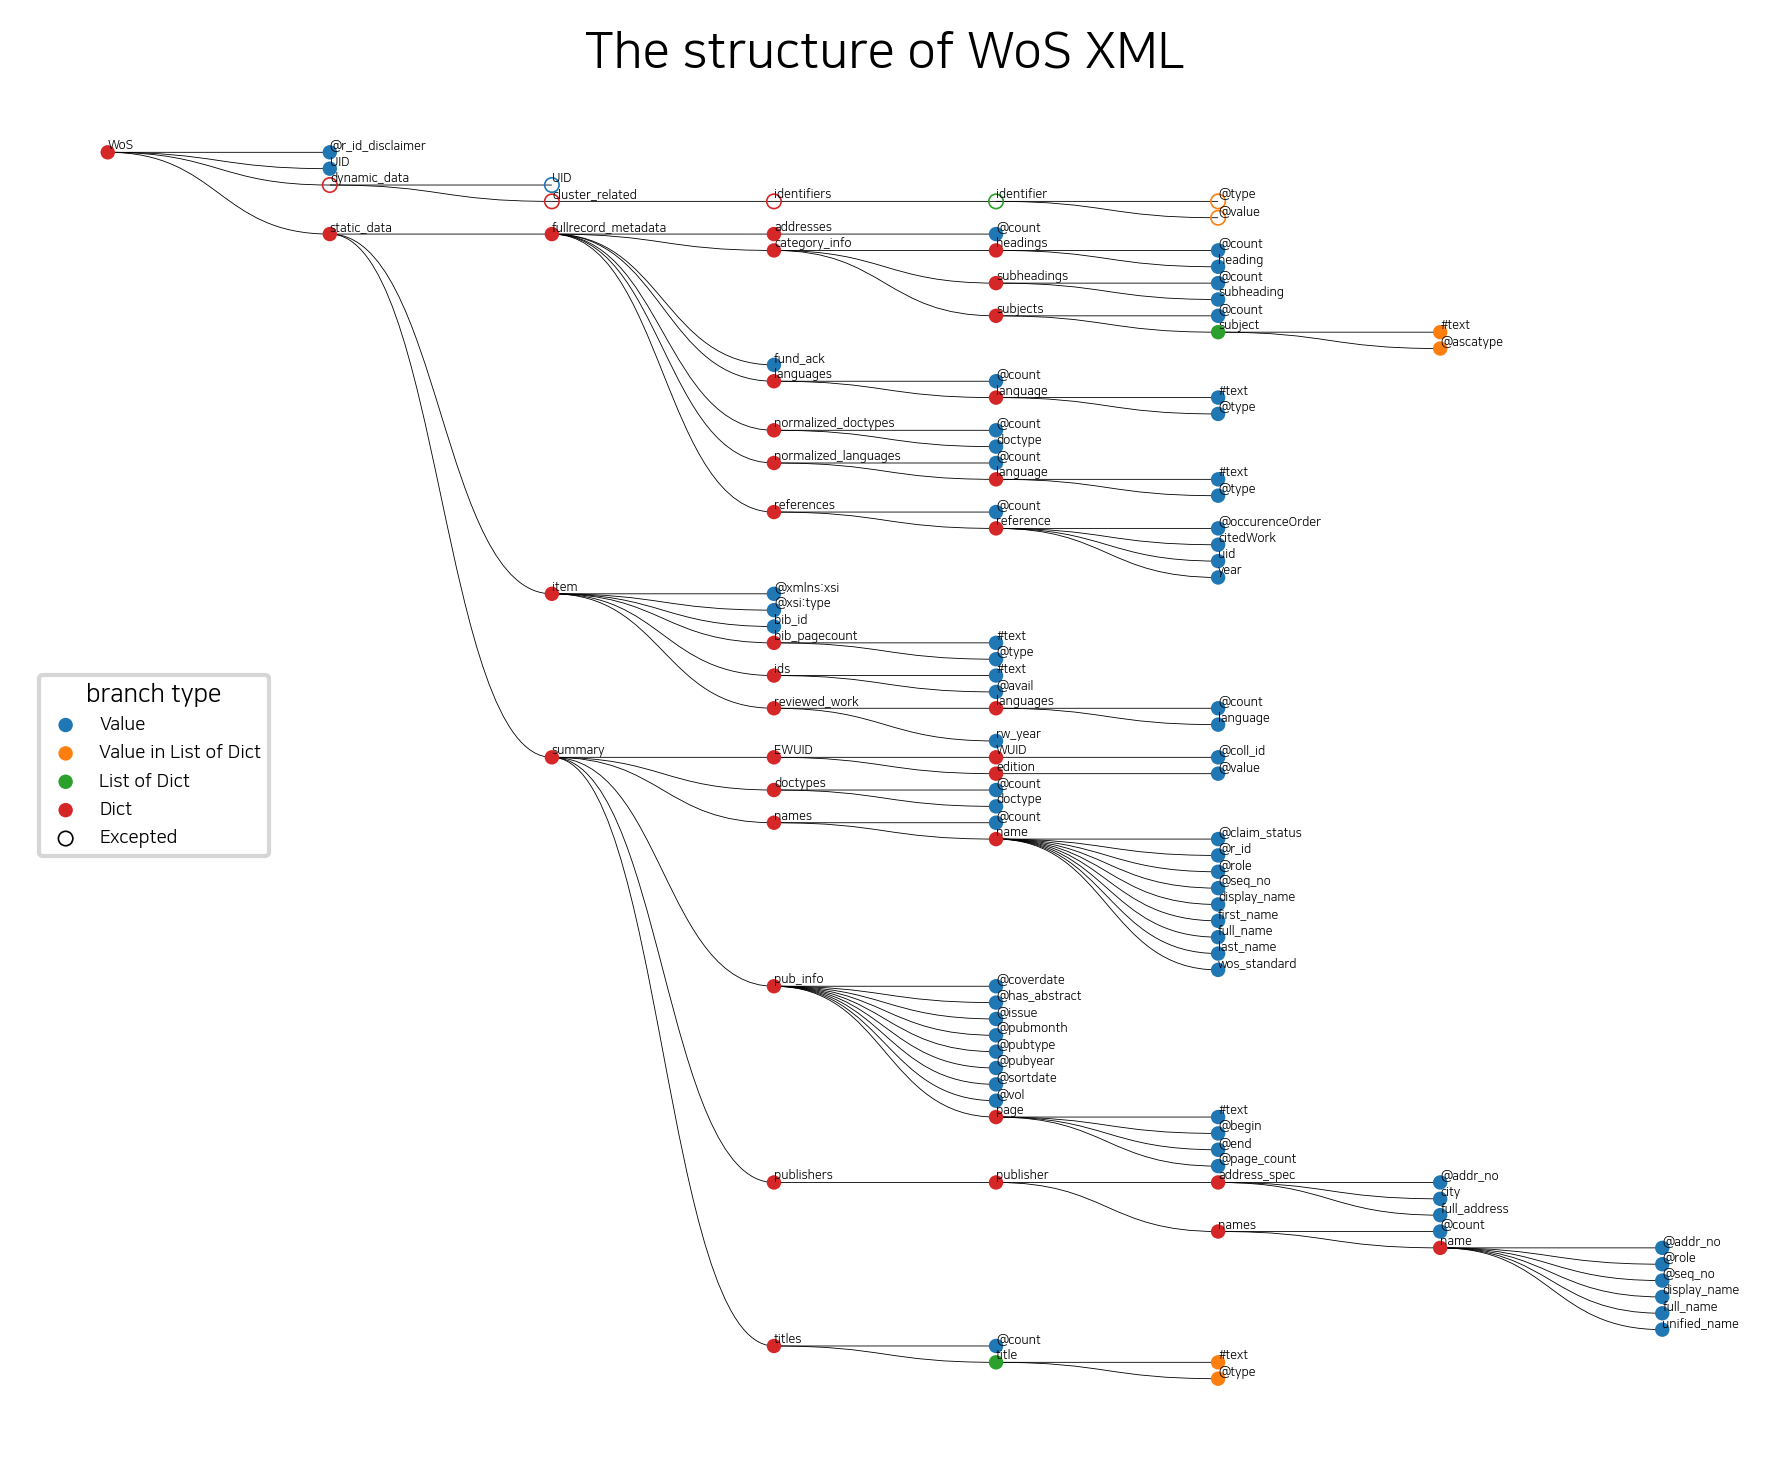

In [909]:
except_keys = ['dynamic_data']
origin = 'WoS'
fig = plot.plot_schema(jsons[0], data_name=origin, origin=origin, except_keys=except_keys, forced={},
          # legend_loc='center left', node_size=12, font_size=3, X_SIZE=6, Y_SIZE=5, DPI=300
                )
plt.tight_layout()
plt.savefig("Structure_WoS_XML.svg")

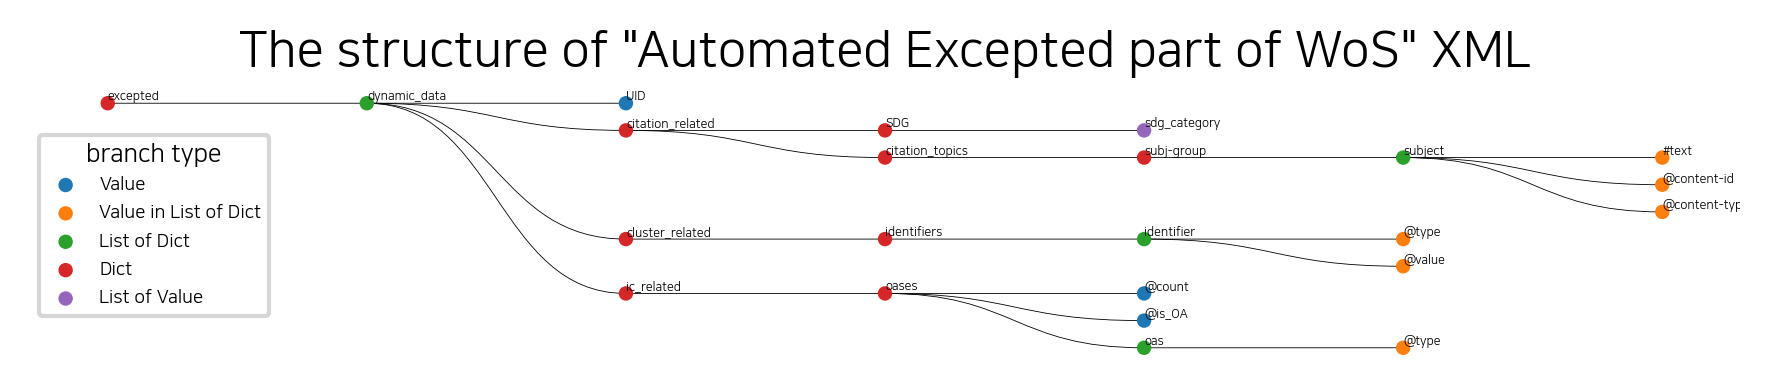

In [908]:
forced = {
    'excepted__dynamic_data__citation_related': 'Dict',
    'excepted__dynamic_data__cluster_related': 'Dict',
    'excepted__dynamic_data__ic_related': 'Dict',
    'excepted__dynamic_data__UID': 'Value',
}
data_name = '"Automated Excepted part of WoS"'
origin = 'excepted'
fig = plot.plot_schema(excepted_part, data_name=data_name, origin=origin, forced=forced,
          legend_loc='bottom left', node_size=12, font_size=3, X_SIZE=6, Y_SIZE=1.4, DPI=300
                )
plt.tight_layout()
plt.savefig("Structure_WoS_XML_Excepted.svg")

In [656]:
key_pairs = processing.json_to_key_pairs(excepted_part, origin)
key_pairs_df = processing.key_pair_to_df(key_pairs, True, forced=forced) # without unique_set, Multiple and Single is appear twice
types = key_pairs.set_index('branch')['type']

# Set the base_key
# This example is only one excepted field.
# If two excepted field is contained, the module can be unstable.
for ekey in except_keys:
    base_key = f'{origin}{sep}{except_keys[0]}'
    excepted_reg = processing.excepted_regularization(excepted_part[ekey], types, base_key=base_key)
    df_ex, df_ex_subs, excepted_part2 = processing.extract_data_from_jsons(excepted_reg, index_key)

100%|████████████████████████████████████| 51167/51167 [02:42<00:00, 315.35it/s]


In [833]:
data_config = {
    'PATH': 'Data_Sample/',
    'KEY': 'UID',
    'SEP': '__',
    'table_name': 'WoS_Sample'
}

processing.save_data([df, df_subs, df_ex, df_ex_subs], data_config)

'Data_Sample/01__WoS_Sample__MN.ftr' is successfully saved.
'Data_Sample/02__WoS_Sample__MN-SUB__static_data__summary__titles__title.ftr' is successfully saved.
'Data_Sample/03__WoS_Sample__MN-SUB__static_data__fullrecord_metadata__category_info__subjects__subject.ftr' is successfully saved.
'Data_Sample/04__WoS_Sample__EX.ftr' is successfully saved.
'Data_Sample/05__WoS_Sample__EX-SUB__ic_related__oases__oas.ftr' is successfully saved.
'Data_Sample/06__WoS_Sample__EX-SUB__cluster_related__identifiers__identifier.ftr' is successfully saved.
'Data_Sample/07__WoS_Sample__EX-SUB__citation_related__SDG__sdg_category.ftr' is successfully saved.
'Data_Sample/08__WoS_Sample__EX-SUB__citation_related__citation_topics__subj-group__subject.ftr' is successfully saved.


In [834]:
# From here, the SEP means separation for the tabular file like 'csv'
data_config = {
    'PATH': 'Data_Sample/',
    'KEY': 'UID',
    'SEP': '__',
    'table_name': 'WoS_Sample',
    'Conv_DATETIME': False,
}

params = dict(Extra_ratio=1.5, 
              Min_Year=1900, 
              Max_Year=2100, 
              unique_ratio_th=.5, 
              freq_ratio_th=1e-3)

PATH = data_config['PATH']
flist = sorted([x for x in os.listdir(PATH) if '.ftr' in x])
df_descs = []
for f in flist:
    data_config = preview.update_data_config(f, data_config)
    df_desc = preview.get_Table_Description(data_config, params)
    df_descs.append(df_desc)

Generate the Description file for table `01__WoS_Sample__MN`
Generate the Description file for table `02__WoS_Sample__MN-SUB__static_data__summary__titles__title`
Generate the Description file for table `03__WoS_Sample__MN-SUB__static_data__fullrecord_metadata__category_info__subjects__subject`
Generate the Description file for table `04__WoS_Sample__EX`
Generate the Description file for table `05__WoS_Sample__EX-SUB__ic_related__oases__oas`
Generate the Description file for table `06__WoS_Sample__EX-SUB__cluster_related__identifiers__identifier`
Generate the Description file for table `07__WoS_Sample__EX-SUB__citation_related__SDG__sdg_category`
Generate the Description file for table `08__WoS_Sample__EX-SUB__citation_related__citation_topics__subj-group__subject`


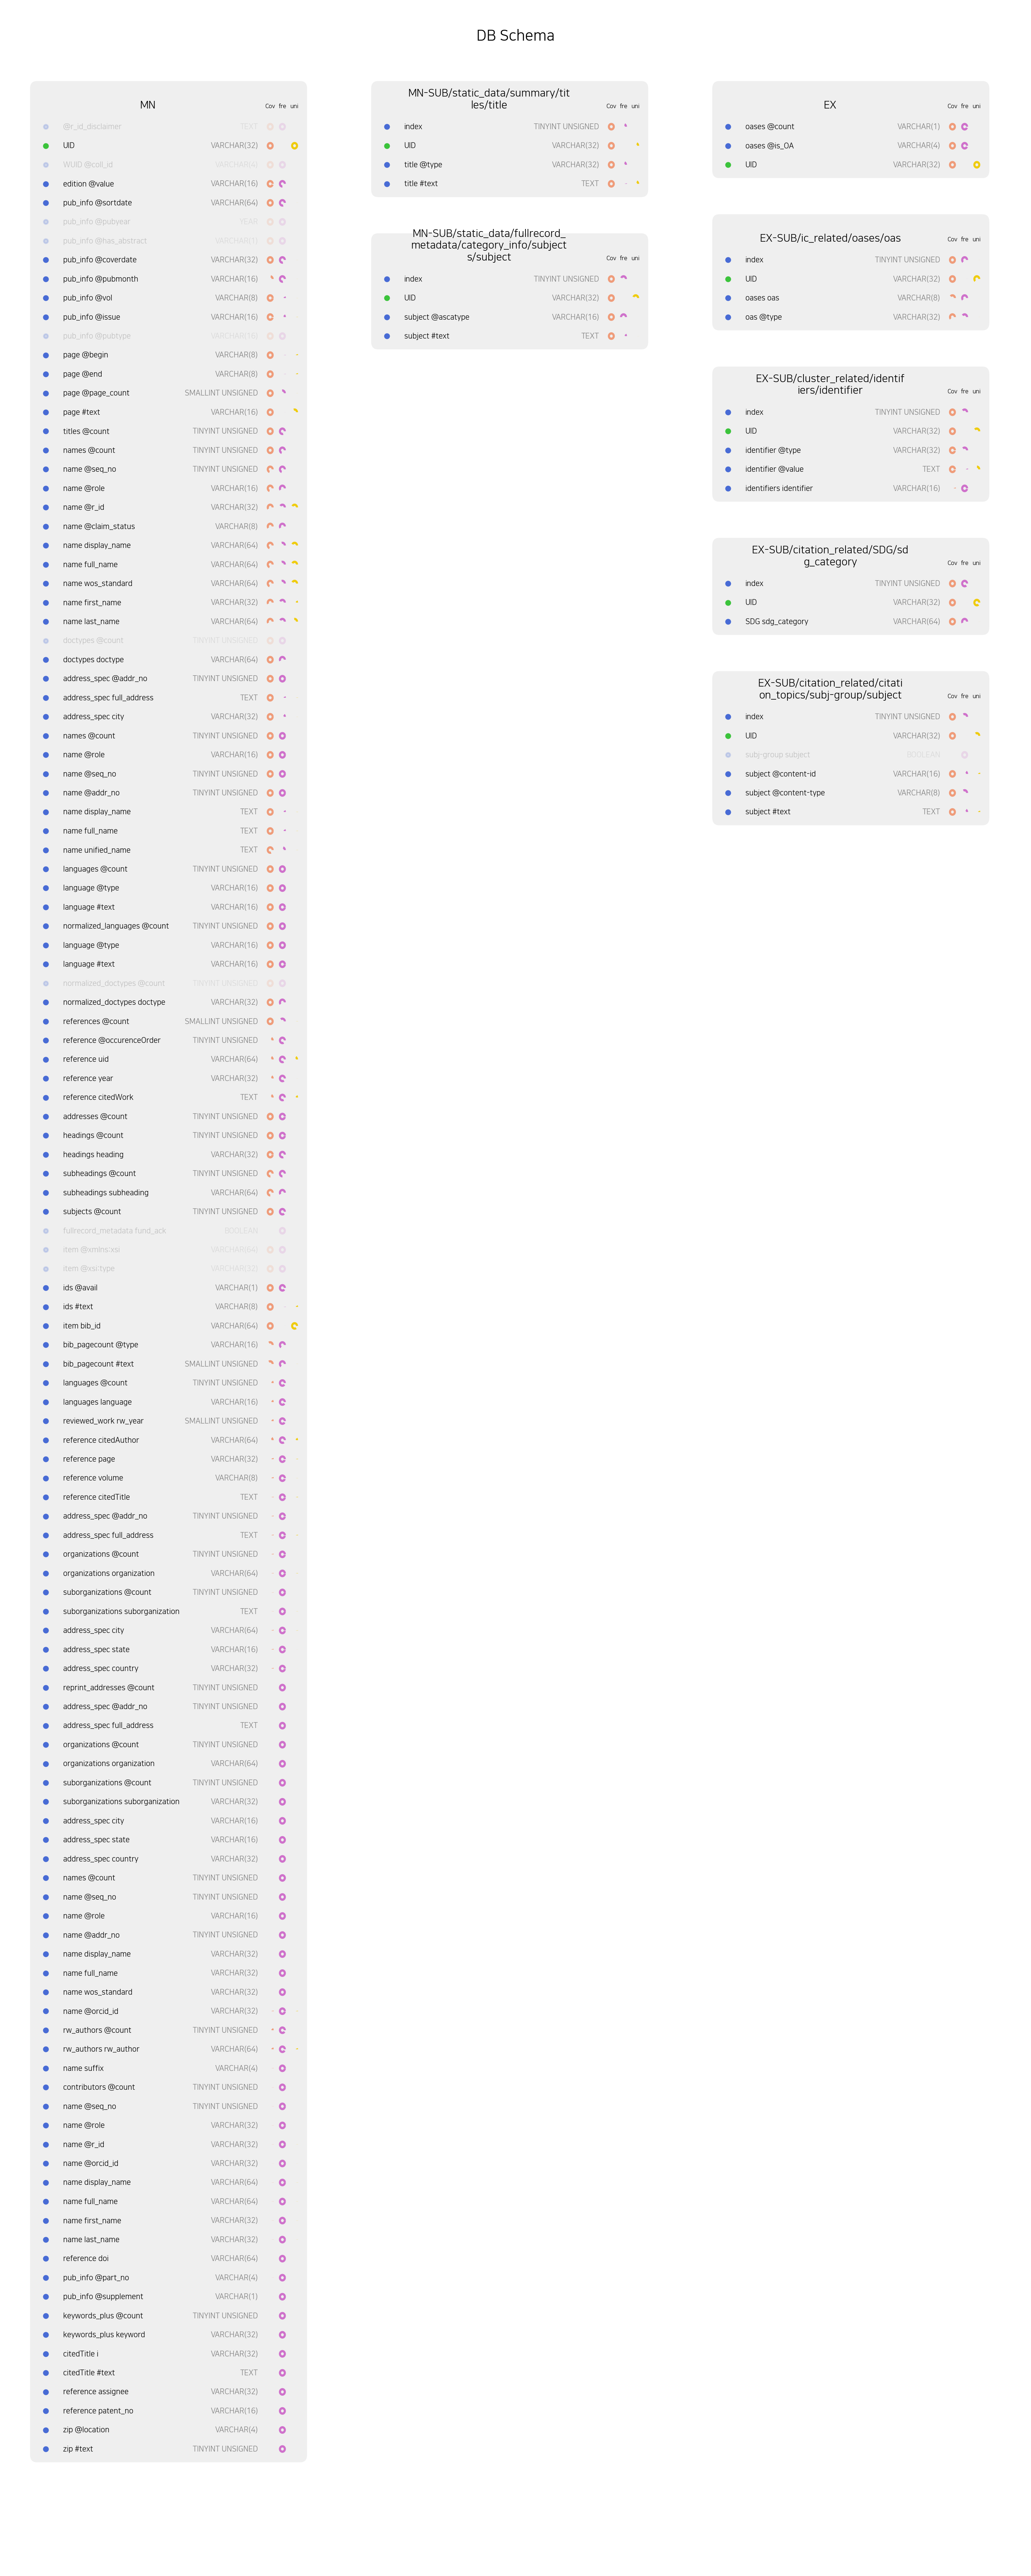

In [918]:
# legend_loc='center left', node_size=12, font_size=3, X_SIZE=6, Y_SIZE=5, DPI=300
node_size=8
font_size=5
X_SIZE=10
Y_SIZE=24
DPI=300

title='DB Schema'
sep='__'
x_unit=1
table_unit = x_unit*14
features = ['Coverage', 'freq', 'uniq_ratio']

# plt.rcParams['svg.fonttype'] = 'path'
svg_fonttype = 'none'
#svg.fonttype : 'path'         # How to handle SVG fonts:
#    'none': Assume fonts are installed on the machine where the SVG will be viewed.
#    'path': Embed characters as paths -- supported by most SVG renderers
#    'svgfont': Embed characters as SVG fonts -- supported only by Chrome,
#               Opera and Safarids



draw_schema()
plt.savefig("test.svg")

In [917]:
def draw_schema(node_size=8, font_size=5, X_SIZE=10, Y_SIZE=24, title='DB Schema', x_unit=1, table_unit=14, features=['Coverage', 'freq', 'uniq_ratio'], DPI=300, svg_fonttype='none', sep='__'):
    import matplotlib.patches as mpatches
    from matplotlib.patches import Wedge
    
    def write_item():
        x = x_base
        y = y_base-i
        # name = idx.split(sep)[-1]
        
        name = " ".join(idx.split(sep)[-2:])
        type = df_desc.loc[idx, 'Type']
        fts = df_desc.loc[idx, features]
        freq = df_desc.loc[idx, 'freq']
        colors = ['lightsalmon', 'orchid', 'gold']
        color = 'royalblue'
        if freq == 1.: # freq
            alpha = 0.2
        else:
            alpha = 1.
            
        if name == index_key:
            color = 'limegreen'
        
        plt.scatter(x, y, alpha=alpha, s=node_size, c=color)
        plt.text(x+x_unit, y, name, alpha=alpha, ha='left', va='center', fontdict=dict(fontsize=font_size)) # Name
        plt.text(x+x_unit+table_unit*.8, y, type, alpha=alpha, ha='right', va='center', color='grey', fontdict=dict(fontsize=font_size)) # Type
        # Coverage, freq, uniq_ratio
        for j, v in enumerate(fts):
            _wedge = mpatches.Wedge((x+x_unit+table_unit*(.85 + 0.05*j), y), 0.2, 0, 360*v, alpha=alpha, width=0.12, ec="none", fc=colors[j])
            ax.add_artist(_wedge)
    
    
    def split_title_line(title_text, max_words=24):  # , max_words=None):
        """
        A function that splits any string based on specific character
        (returning it with the string), with maximum number of words on it
        """
        splited = []
        text = title_text[:]
        while text != '':
            splited.append(text[:max_words])
            text = text[max_words:]
        return '\n'.join(splited)
    
    
    def base_set(x_base, y_base, fi, max_words):
        f = flist[fi]
        table_name = "/".join(f.split('/')[-1].split(sep)[2:])[:-4]
        table_name = split_title_line(table_name, max_words=max_words)
        
        if (table_name == 'EX') | (fi == 1):
            x_base += table_unit*1.4
            y_base = 0
        elif fi != 0:
            y_base -= i+5
        plt.text(x_base+table_unit*.42, y_base+1, table_name, ha='center', fontdict=dict(fontsize=font_size*1.4))
        for j, v in enumerate(features):
            plt.text(x_base+x_unit+table_unit*(.85 + 0.05*j), y_base+1, v[:3], ha='center', fontdict=dict(fontsize=font_size*.8))
        return x_base, y_base
    
    
    def set_bbox():
        box = mpatches.FancyBboxPatch((x_base-x_unit*.5, y_base-i-.3), table_unit*1.08, i+2.3, ec="none", fc='grey', alpha=.12,
                                boxstyle=mpatches.BoxStyle("Round", pad=.4))
        ax.add_artist(box)
    
    
    N_ROW = 1
    N_COL = 1
    plt.rcParams['font.family'] = ['NanumSquare', 'Helvetica']
    plt.rcParams['svg.fonttype'] = svg_fonttype
    
    fig=plt.figure(figsize = (X_SIZE*N_COL,Y_SIZE*N_ROW), dpi=DPI)
    spec = gridspec.GridSpec(ncols=N_COL, nrows=N_ROW, figure=fig, )#, width_ratios=[1,1,.1], wspace=.3)
    axes = []
    axi=0
    ax = fig.add_subplot(spec[axi//N_COL,axi%N_COL]) # row, col
    
    ########### Draw ###########
    x_base, y_base = 0, 0
    patches = []
    for fi, df_desc in enumerate(df_descs):
        x_base, y_base = base_set(x_base, y_base, fi, max_words=30)
        for i, idx in enumerate(df_desc.index):
            write_item() ## a line
        set_bbox()
    
    plt.xlim([-x_unit*2, table_unit*4])
    
    plt.tight_layout()
    plt.axis('off')
    plt.title(title, y=0.985, fontdict=dict(fontsize=font_size*2))
    
    return fig

# Excepted branch

## Consider Excepted part
- accumulate the date
    - single > multiple
    - couverage checing
    - coloring
    - optimizion

In [ ]:
data_config = {
    'PATH': 'Data_Sample/',
    'SEP': ',',
    'file_name': 'file_name', # Dummy init value
    'file_type': 'csv', # Dummy init value
    'table_name': 'table_name', # Dummy init value for Exporting
    'out_path': '../Data/SQL/', # Update as needed
    'Conv_DATETIME': False,
}

In [20]:
PATH = '../Data/Funding/KR_NTIS/'
SEP = '\t'
Port = 0 # Port for DB with host
CHARACTER_SET = 'utf8mb4'
COLLATE = 'utf8mb4_unicode_520_ci'

params = dict(Extra_ratio=1.5, 
              Min_Year=1900, 
              Max_Year=2100, 
              unique_ratio_th=.5, 
              freq_ratio_th=1e-3)

db_config = {
    'host': 'localhost',  # Update as needed
    'user': 'user',       # Update as needed
    'password': '1234',       # Update as needed
    'database': 'KR_NTIS_2023_raw'  # Update as needed
}

data_config = {
    'PATH': PATH,
    'SEP': SEP,
    'file_name': 'file_name', # Dummy init value
    'file_type': 'csv', # Dummy init value
    'table_name': 'table_name', # Dummy init value for Exporting
    'out_path': '../Data/SQL/', # Update as needed
    'Conv_DATETIME': False,
}

In [ ]:
manage.init_MySQL()
try:
    manage.drop_DB(db_config['database'], db_config)
except:
    pass
manage.create_DB(db_config['database'], CHARACTER_SET, COLLATE, db_config)


# Generate the Tabular File list
flist = sorted([x for x in os.listdir(PATH) if 'raw.ftr' in x])
for f in tqdm(flist[:]):
    data_config = preview.update_data_config(f, data_config)
    df_desc = preview.get_Table_Description(data_config, params)
    
    # Generate and execute CREATE TABLE SQL
    manage.create_table(data_config, db_config)
    manage.fill_table_from_file(data_config, db_config)
    manage.set_index(db_config, data_config)
    manage.optimize_table(db_config, data_config)

 * Starting MySQL database server mysqld
   ...done.
Failed to drop database `KR_NTIS_2023_raw`. Error: (1049, "Unknown database 'KR_NTIS_2023_raw'")
Database `KR_NTIS_2023_raw` created successfully.


  0%|                                                    | 0/16 [00:00<?, ?it/s]

Generate the Description file for table `1_Projects_raw`
Table `1_Projects_raw` created successfully.
Data inserted into table `1_Projects_raw` successfully.
Set Index the 과제고유번호 on `1_Projects_raw` successfully.


In [ ]:
manage.backup_database_subprocess(db_config, data_config)

In [81]:
_df_subs.keys()

dict_keys(['static_data__summary__titles__title', 'static_data__summary__names__name', 'static_data__fullrecord_metadata__references__reference', 'static_data__fullrecord_metadata__category_info__subjects__subject', 'dynamic_data__citation_related__citation_topics__subj-group__subject'])